# **Cargar Dataset Base (Airbnb Kaggle)**



In [ ]:
import pandas as pd

# Cargar dataset
df_airbnb = pd.read_csv('/content/AB_NYC_2019.csv')
# Mostrar las primeras 5 líneas
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## **Análisis exploratorio**

In [ ]:
# ANÁLISIS EXPLORATORIO INICIAL — KAGGLE
# Antes de limpiar, inspeccionamos el dataset para entender su estructura, detectar problemas de calidad y justificar cada decisión de limpieza posterior.

print("🔹 Dimensiones del dataset:")
print(df_airbnb.shape)

print("\n🔹 Primeras filas:")
print(df_airbnb.head())

print("\n🔹 Tipos de datos:")
print(df_airbnb.dtypes)

# Identificamos qué columnas tienen nulos y cuántos, para decidir si eliminar filas o imputar valores.
print("\n🔹 Valores nulos por columna:")
print(df_airbnb.isnull().sum())

# Verificamos si existen filas duplicadas que puedan sesgar los resultados del análisis.
print("\n🔹 Duplicados:")
print(df_airbnb.duplicated().sum())

# Las estadísticas descriptivas nos permiten detectar outliers en precio (máx 10,000) y minimum_nights (máx 1,250) que deberemos tratar en la limpieza.
print("\n🔹 Estadísticas descriptivas:")
print(df_airbnb.describe())

# Revisamos la distribución de variables categóricas clave para entender el balance del dataset por tipo y zona.
print("\n🔹 Distribución de room_type:")
print(df_airbnb['room_type'].value_counts())

print("\n🔹 Distribución de neighbourhood_group:")
print(df_airbnb['neighbourhood_group'].value_counts())

🔹 Dimensiones del dataset:
(48895, 16)

🔹 Primeras filas:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     

## **Justificación del filtro de precio**

In [ ]:
# ANÁLISIS DE OUTLIERS - PRECIO
# Calculamos percentiles para definir un corte justificado.

print("🔹 Distribución de precios:")
print(df_airbnb['price'].describe())

print(f"\n🔹 Percentil 95: {df_airbnb['price'].quantile(0.95):.0f} USD")
print(f"🔹 Percentil 99: {df_airbnb['price'].quantile(0.99):.0f} USD")
print(f"🔹 Precio máximo: {df_airbnb['price'].max():.0f} USD")
print(f"🔹 Precios en 0: {(df_airbnb['price'] == 0).sum()}")
print(f"🔹 Precios < 10: {(df_airbnb['price'] < 10).sum()}")
print(f"🔹 Precios > 800: {(df_airbnb['price'] > 800).sum()}")

🔹 Distribución de precios:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

🔹 Percentil 95: 355 USD
🔹 Percentil 99: 799 USD
🔹 Precio máximo: 10000 USD
🔹 Precios en 0: 11
🔹 Precios < 10: 11
🔹 Precios > 800: 420


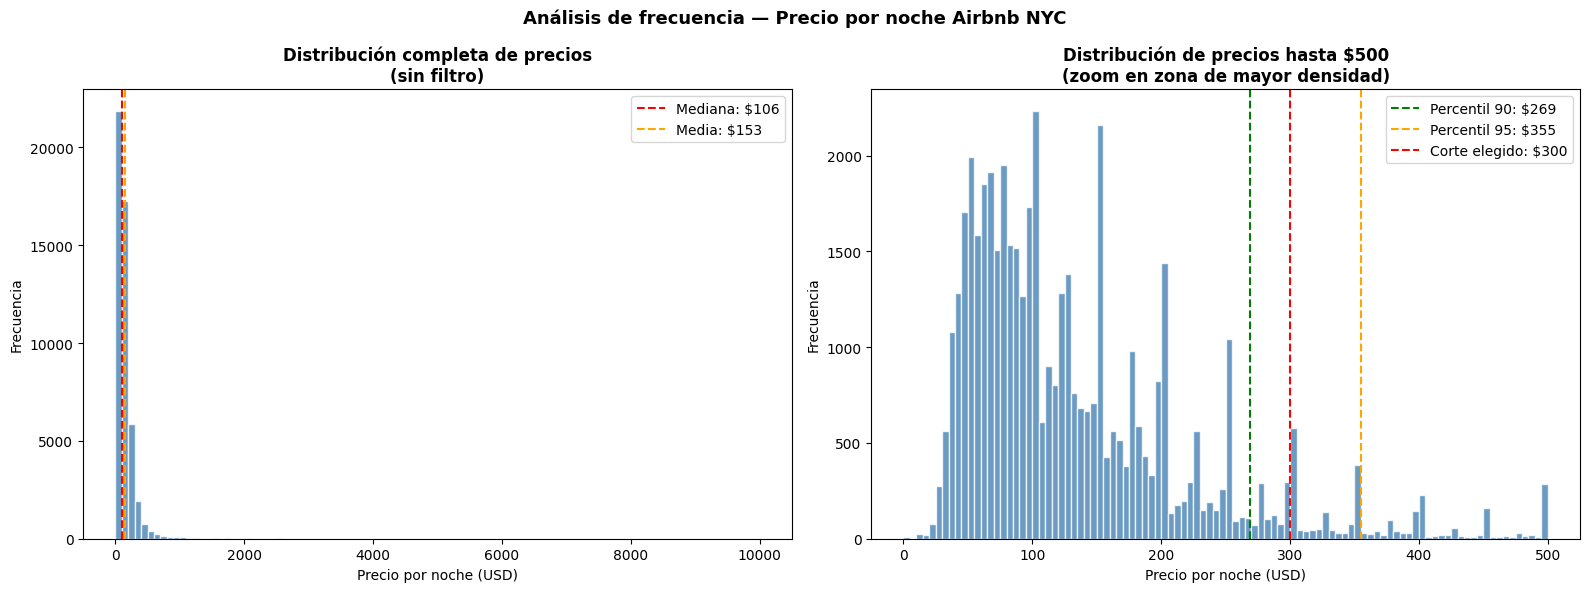

📊 Estadísticos de distribución:
   Skewness (asimetría): 19.119
   Kurtosis: 585.673
   Media: $152.72
   Mediana: $106.00
   Diferencia media-mediana: $46.72

📊 Percentiles clave:
   Percentil 50: $106
   Percentil 75: $175
   Percentil 90: $269
   Percentil 95: $355
   Percentil 99: $799

📊 Registros hasta $300: 45538 (93.1%)
📊 Registros hasta $800: 48475 (99.1%)


In [ ]:
# ANÁLISIS DE DISTRIBUCIÓN DE PRECIOS
# Antes de definir el filtro, analizamos la frecuencia de los datos para identificar hacia qué lado se inclina la cola y dónde se concentra la mayoría del mercado
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Histograma completo
axes[0].hist(df_airbnb['price'], bins=100,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución completa de precios\n(sin filtro)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Precio por noche (USD)', fontsize=10)
axes[0].set_ylabel('Frecuencia', fontsize=10)
axes[0].axvline(df_airbnb['price'].median(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mediana: ${df_airbnb['price'].median():.0f}")
axes[0].axvline(df_airbnb['price'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Media: ${df_airbnb['price'].mean():.0f}")
axes[0].legend()

# Gráfico 2: Histograma hasta $500 para ver mejor
df_zoom = df_airbnb[df_airbnb['price'] <= 500]
axes[1].hist(df_zoom['price'], bins=100,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de precios hasta $500\n(zoom en zona de mayor densidad)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Precio por noche (USD)', fontsize=10)
axes[1].set_ylabel('Frecuencia', fontsize=10)
axes[1].axvline(df_airbnb['price'].quantile(0.90), color='green',
                linestyle='--', linewidth=1.5,
                label=f"Percentil 90: ${df_airbnb['price'].quantile(0.90):.0f}")
axes[1].axvline(df_airbnb['price'].quantile(0.95), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Percentil 95: ${df_airbnb['price'].quantile(0.95):.0f}")
axes[1].axvline(300, color='red', linestyle='--', linewidth=1.5,
                label='Corte elegido: $300')
axes[1].legend()

plt.suptitle('Análisis de frecuencia — Precio por noche Airbnb NYC',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticos de distribución
from scipy import stats

skewness = df_airbnb['price'].skew()
kurtosis = df_airbnb['price'].kurtosis()

print("📊 Estadísticos de distribución:")
print(f"   Skewness (asimetría): {skewness:.3f}")
print(f"   Kurtosis: {kurtosis:.3f}")
print(f"   Media: ${df_airbnb['price'].mean():.2f}")
print(f"   Mediana: ${df_airbnb['price'].median():.2f}")
print(f"   Diferencia media-mediana: ${df_airbnb['price'].mean() - df_airbnb['price'].median():.2f}")

print(f"""
📊 Percentiles clave:
   Percentil 50: ${df_airbnb['price'].quantile(0.50):.0f}
   Percentil 75: ${df_airbnb['price'].quantile(0.75):.0f}
   Percentil 90: ${df_airbnb['price'].quantile(0.90):.0f}
   Percentil 95: ${df_airbnb['price'].quantile(0.95):.0f}
   Percentil 99: ${df_airbnb['price'].quantile(0.99):.0f}
""")

print(f"📊 Registros hasta $300: {(df_airbnb['price'] <= 300).sum()} ({(df_airbnb['price'] <= 300).mean()*100:.1f}%)")
print(f"📊 Registros hasta $800: {(df_airbnb['price'] <= 800).sum()} ({(df_airbnb['price'] <= 800).mean()*100:.1f}%)")

El histograma deja claro que la mayoría de propiedades en Airbnb NYC tiene precios relativamente bajos o medios, mientras que solo unas pocas alcanzan precios muy altos. Esas propiedades premium son pocas, pero afectan bastante el promedio general. Por eso la media llega a 153, mientras que la mediana es solo $106. En otras palabras, el precio “típico” del mercado está mucho más cerca de la mediana que de la media.

Cuando hacemos zoom al gráfico, se nota que después de los 300 por noche la cantidad de propiedades cae muchísimo. Además, el percentil 90 está en $269, lo que significa que el 90% de los alojamientos de Airbnb NYC cuesta menos que eso.

Por esa razón, filtrar propiedades con precios mayores a $300 tiene sentido para el análisis, el corte mantiene más del 93% de los datos y elimina solo un pequeño grupo de propiedades de lujo que se comportan de forma muy distinta al resto del mercado.


## **Limpieza inicial: valores nulos, duplicados, formatos.**

In [ ]:
# LIMPIEZA

# Eliminar columnas innecesarias
df_airbnb = df_airbnb.drop(columns=['id', 'host_id', 'host_name', 'last_review', 'name'])

# Manejar nulos: reviews_per_month → rellenar con 0
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)

# Eliminar duplicados
df_airbnb = df_airbnb.drop_duplicates()

# FILTRO DE OUTLIERS - PRECIO
# El análisis de distribución muestra que el precio máximo es 10,000 USD y hay 11 registros con precio 0, que representan errores de carga
# Estos valores extremos distorsionan el análisis sin aportar información representativa
# Por eso filtramos: price >= 10 (elimina los 11 errores) y price <= 800 (elimina outliers del percentil 99 hacia arriba)
# El 90%+ de propiedades se concentra entre $10 y $300
# Eliminar extremos mejora la confiabilidad del modelo predictivo
df_airbnb = df_airbnb[(df_airbnb['price'] >= 10) & (df_airbnb['price'] <= 300)]

# Filtrar minimum_nights <= 365
df_airbnb = df_airbnb[df_airbnb['minimum_nights'] <= 365]

# Resetear índice
df_airbnb = df_airbnb.reset_index(drop=True)

print(f"✅ Kaggle limpio: {df_airbnb.shape}")
print(df_airbnb.isnull().sum())

✅ Kaggle limpio: (45514, 11)
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [ ]:
# VERIFICACIÓN FINAL - KAGGLE
# Confirmamos que el dataset limpio tiene rangos coherentes y que no quedaron nulos en variables clave

print("✅ Dataset Kaggle limpio:")
print(f"   Filas finales: {df_airbnb.shape[0]}")
print(f"   Columnas: {df_airbnb.shape[1]}")

print("\n🔹 Rango de variables clave:")
print(df_airbnb[['price', 'minimum_nights', 'reviews_per_month',
                  'availability_365', 'calculated_host_listings_count']].describe())

print("\n🔹 Nulos restantes:")
print(df_airbnb.isnull().sum())

✅ Dataset Kaggle limpio:
   Filas finales: 45514
   Columnas: 11

🔹 Rango de variables clave:
              price  minimum_nights  reviews_per_month  availability_365  \
count  45514.000000    45514.000000       45514.000000      45514.000000   
mean     118.312915        6.724524           1.107499        108.823593   
std       65.892252       16.011668           1.611380        130.136910   
min       10.000000        1.000000           0.000000          0.000000   
25%       65.000000        1.000000           0.050000          0.000000   
50%      100.000000        2.000000           0.390000         38.000000   
75%      155.000000        5.000000           1.620000        215.000000   
max      300.000000      365.000000          58.500000        365.000000   

       calculated_host_listings_count  
count                    45514.000000  
mean                         6.296019  
std                         29.729448  
min                          1.000000  
25%                  

# **Cargar Dataset Base (Inside Airbnb)**

In [ ]:
# DATASET 2 - Listings largo (Inside Airbnb)

# CARGA
df_listings = pd.read_csv(
    '/content/listings.csv',
    on_bad_lines='skip',
    quotechar='"',
    escapechar='\\',
    engine='python'
)
print(f"Dimensiones originales: {df_listings.shape}")

# PRIMEROS 5 VALORES
df_listings.head()

Dimensiones originales: (36442, 85)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,https://www.airbnb.com/rooms/2595,20260213082241,2026-02-14,city scrape,Skylit Studio Oasis | Midtown Manhattan Sanctuary,Prime Midtown | Spacious 500 Sq Ft | Pyramid S...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2845,...,4.80,4.81,4.40,NaN,NaN,3,3,0,0,0.24
1,6848,https://www.airbnb.com/rooms/6848,20260213082241,2026-02-14,previous scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.97
2,6872,https://www.airbnb.com/rooms/6872,20260213082241,2026-02-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260213082241,2026-02-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,NaN,1,0,1,0,1.26
4,7097,https://www.airbnb.com/rooms/7097,20260213082241,2026-02-13,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,OSE-STRREG-0000008,NaN,2,0,2,0,2.16


In [ ]:
# LIMPIEZA

# Quedarse solo con las 2 columnas necesarias
df_listings = df_listings[['neighbourhood_group_cleansed', 'review_scores_location']]

# Eliminar filas donde review_scores_location sea nulo o igual a 0
df_listings = df_listings[
    df_listings['review_scores_location'].notna() &
    (df_listings['review_scores_location'] != 0)
]

# Calcular promedio por distrito → df_scores_ubicacion
df_scores_ubicacion = (
    df_listings
    .groupby('neighbourhood_group_cleansed')['review_scores_location']
    .mean()
    .reset_index()
    .rename(columns={
        'neighbourhood_group_cleansed': 'distrito',
        'review_scores_location': 'score_ubicacion_promedio'
    })
)

print("✅ Scores de ubicación por distrito:")
print(df_scores_ubicacion)

✅ Scores de ubicación por distrito:
        distrito  score_ubicacion_promedio
0          Bronx                  4.600857
1       Brooklyn                  4.716476
2      Manhattan                  4.790263
3         Queens                  4.710156
4  Staten Island                  4.743218


# **ANÁLITICA DESCRIPTIVA**

## **EDA (5 GRAFICOS)**

### **G1 — Boxplot de precio por distrito**



Lo primero que necesitamos entender antes de cualquier análisis es cómo se distribuye el precio en cada zona de NYC. Este gráfico nos da una foto completa de eso: dónde está la mediana, qué tan dispersos son los precios y si hay zonas con muchos valores extremos. Sin esto no podemos hablar de precios con criterio y primero hay que ver dónde existe y dónde no.

/tmp/ipykernel_5628/3019234355.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


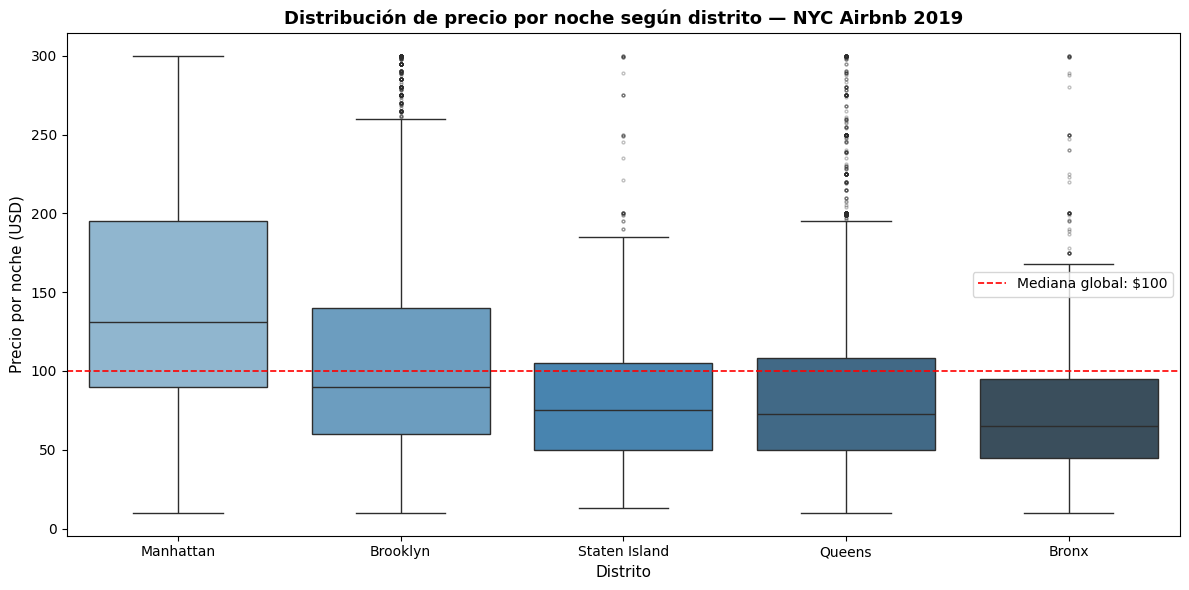


📊 Medianas por distrito:
neighbourhood_group
Manhattan        131.0
Brooklyn          90.0
Staten Island     75.0
Queens            73.0
Bronx             65.0
Name: price, dtype: float64


In [ ]:
# G1 - DISTRIBUCIÓN DE PRECIO POR DISTRITO (UNIVARIADO)
# Objetivo: identificar en qué distritos se concentran los precios premium y cómo varía la dispersión entre zonas
# Variable principal: price × neighbourhood_group

import matplotlib.pyplot as plt
import seaborn as sns

# Ordenamos los distritos de mayor a menor precio mediano para que el gráfico tenga lectura más intuitiva
orden_distritos = (df_airbnb.groupby('neighbourhood_group')['price']
                   .median()
                   .sort_values(ascending=False)
                   .index)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_airbnb,
    x='neighbourhood_group',
    y='price',
    order=orden_distritos,
    palette='Blues_d',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

# Línea de precio mediano global como referencia
mediana_global = df_airbnb['price'].median()
plt.axhline(mediana_global, color='red', linestyle='--',
            linewidth=1.2, label=f'Mediana global: ${mediana_global:.0f}')

plt.title('Distribución de precio por noche según distrito — NYC Airbnb 2019',
          fontsize=13, fontweight='bold')
plt.xlabel('Distrito', fontsize=11)
plt.ylabel('Precio por noche (USD)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# Conclusión de negocio
print("\n📊 Medianas por distrito:")
print(df_airbnb.groupby('neighbourhood_group')['price']
      .median().sort_values(ascending=False))

Manhattan destaca claramente como el distrito más caro de Airbnb NYC. Su mediana llega a casi a $150 y además tiene una gran variabilidad de precios. Esto significa que en la zona hay tanto propiedades relativamente accesibles como alojamientos de lujo bastante costosos.

Brooklyn aparece como el segundo distrito más caro, con una mediana cercana a $90, aunque tiene más outliers que Manhattan. En cambio, Queens, Staten Island y Bronx tienen medianas más bajas, entre 65 y 75, y muestran mercados mucho más dispersos, con menor presencia de propiedades premium pero siendo los "raros" de estos barrios.

También se observa que la mayoría de precios extremadamente altos se concentra en Manhattan y Brooklyn. Esto demuestra que el segmento premium de Airbnb NYC no está distribuido de manera uniforme en toda la ciudad, sino que se concentra principalmente en ciertos distritos.

### **G2 — Precio mediano por tipo de habitación y distrito**


Una vez que sabemos cómo varía el precio por zona, la pregunta natural es: ¿esa variación se explica por el distrito o por el tipo de propiedad? ¿Un departamento entero en Queens cuesta más que una habitación privada en Manhattan? Este gráfico cruza ambas variables al mismo tiempo para ver cuál de las dos pesa más sobre el precio y eso es exactamente lo que necesitamos entender antes de poder hablar de lo que determina un precio.

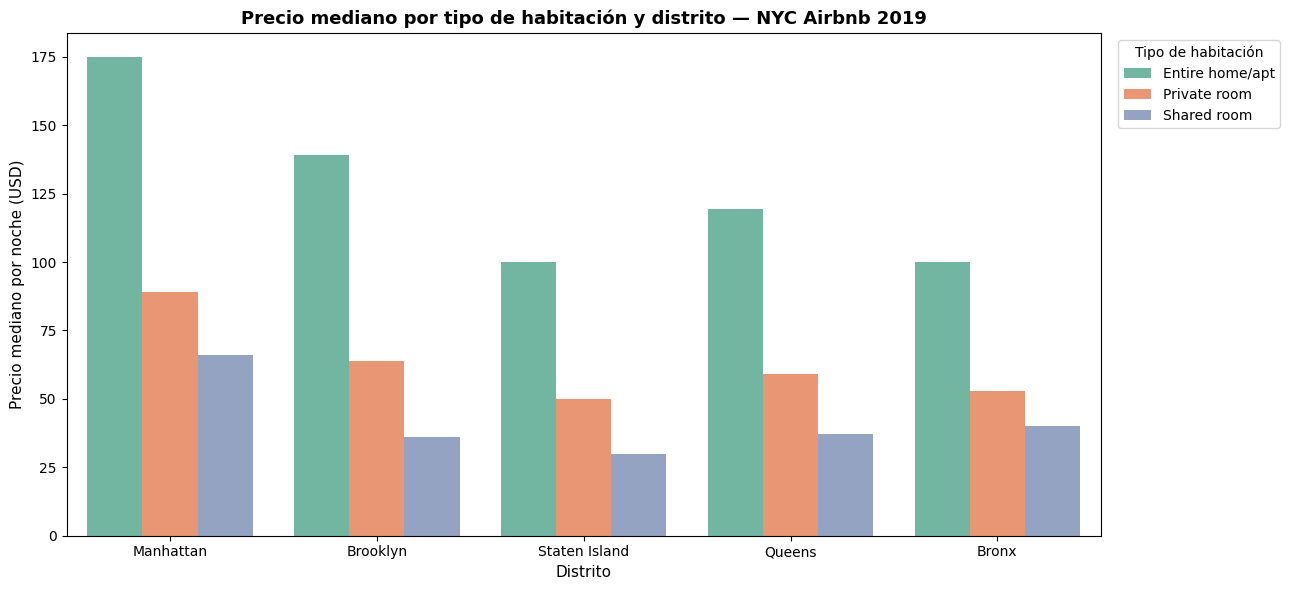


📊 Precio mediano por distrito y tipo:
neighbourhood_group       room_type  precio_mediano
          Manhattan Entire home/apt           175.0
           Brooklyn Entire home/apt           139.0
             Queens Entire home/apt           119.5
      Staten Island Entire home/apt           100.0
              Bronx Entire home/apt           100.0
          Manhattan    Private room            89.0
          Manhattan     Shared room            66.0
           Brooklyn    Private room            64.0
             Queens    Private room            59.0
              Bronx    Private room            53.0
      Staten Island    Private room            50.0
              Bronx     Shared room            40.0
             Queens     Shared room            37.0
           Brooklyn     Shared room            36.0
      Staten Island     Shared room            30.0


In [ ]:
# G2 - PRECIO MEDIANO POR TIPO DE HABITACIÓN Y DISTRITO (BIVARIADO)
# Objetivo: comparar el efecto del distrito vs. el tipo de habitación sobre el precio.
#Si la variación entre distritos supera la variación entre tipos, el distrito es el factor dominante en la determinación del precio premium
# Variables: price × room_type × neighbourhood_group

# Calculamos precio mediano por combinación distrito + tipo
df_g2 = (df_airbnb.groupby(['neighbourhood_group', 'room_type'])['price']
         .median()
         .reset_index()
         .rename(columns={'price': 'precio_mediano'}))

plt.figure(figsize=(13, 6))

sns.barplot(
    data=df_g2,
    x='neighbourhood_group',
    y='precio_mediano',
    hue='room_type',
    palette='Set2',
    order=orden_distritos  # mismo orden que G1
)

plt.title('Precio mediano por tipo de habitación y distrito — NYC Airbnb 2019',
          fontsize=13, fontweight='bold')
plt.xlabel('Distrito', fontsize=11)
plt.ylabel('Precio mediano por noche (USD)', fontsize=11)
plt.legend(title='Tipo de habitación', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Conclusión de negocio
print("\n📊 Precio mediano por distrito y tipo:")
print(df_g2.sort_values('precio_mediano', ascending=False).to_string(index=False))

El gráfico muestra que tanto el distrito como el tipo de habitación influyen en el precio, pero de maneras diferentes. En todos los distritos se repite el mismo patrón: los “Entire home/apt” son siempre los más caros, después vienen los “Private room” y finalmente los “Shared room”. Esto demuestra que el tipo de habitación tiene un impacto bastante claro y constante sobre el precio.

Sin embargo, el distrito hace que esa diferencia aumente o disminuya mucho más. Por ejemplo, un “Entire home/apt” en Manhattan tiene una mediana de $191, mientras que el mismo tipo de alojamiento en Bronx o Staten Island ronda los 100. Es decir, por el mismo formato de propiedad puede existir casi el doble de diferencia dependiendo de la ubicación.

Esto sugiere que el tipo de habitación define el precio base del alojamiento, pero el distrito es lo que realmente empuja el precio hacia arriba o limita cuánto puede valer.

### **G3 — Disponibilidad vs. precio coloreado por tipo**


La pregunta de negocio no es solo sobre precio sino también habla de alta ocupación. Como no tenemos ocupación directa, usamos availability_365 al revés: menos días disponibles al año significa que la propiedad está más ocupada. Este gráfico nos permite ver si precio alto y alta ocupación van juntos o si son objetivos que se contradicen, segmentado por tipo de propiedad para ver si el patrón cambia según el formato del alojamiento.

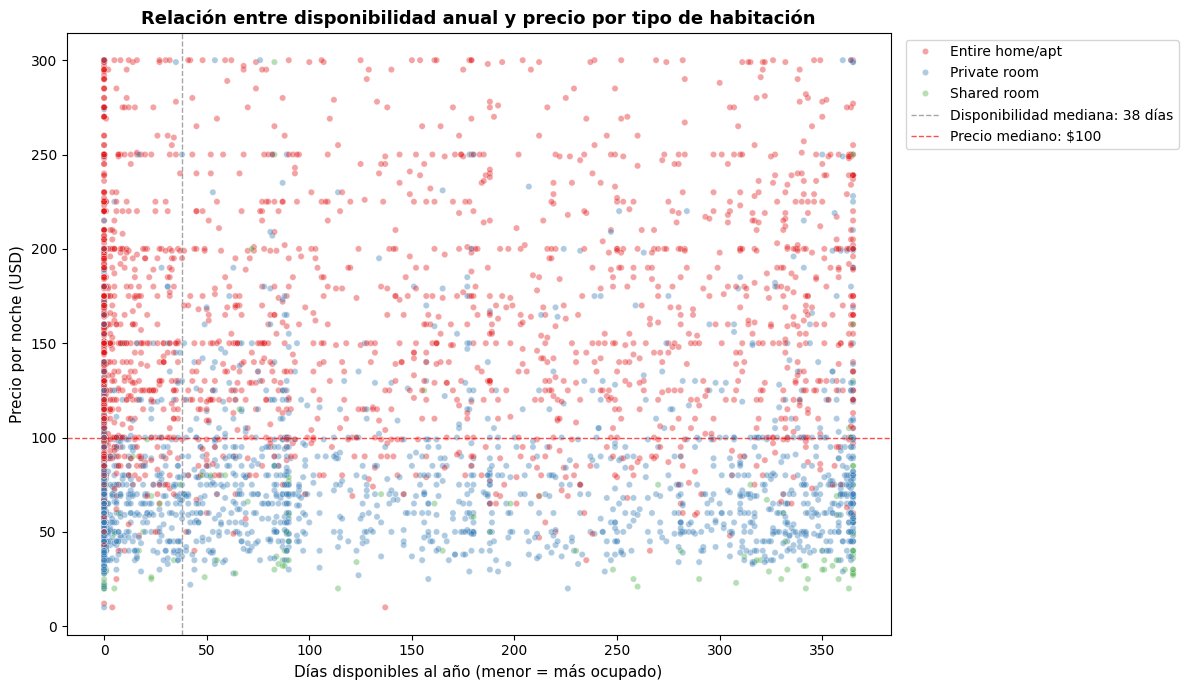

In [ ]:
# G3 — PRECIO VS. DISPONIBILIDAD ANUAL POR TIPO (BIVARIADO)
# Objetivo: explorar si las propiedades con precio premium tienen menor disponibilidad (mayor ocupación).
# Usamos availability_365 como proxy inverso de ocupación:, teniendo que menos días disponibles = más demanda sostenida.
# Variables: price × availability_365 × room_type

# Tomamos una muestra para que el scatter no sea ilegible
df_g3 = df_airbnb.sample(n=5000, random_state=42)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_g3,
    x='availability_365',
    y='price',
    hue='room_type',
    palette='Set1',
    alpha=0.4,
    s=20
)

# Líneas de referencia para cuadrantes interpretativos
plt.axvline(df_airbnb['availability_365'].median(), color='gray',
            linestyle='--', linewidth=1, alpha=0.7,
            label=f"Disponibilidad mediana: {df_airbnb['availability_365'].median():.0f} días")
plt.axhline(df_airbnb['price'].median(), color='red',
            linestyle='--', linewidth=1, alpha=0.7,
            label=f"Precio mediano: ${df_airbnb['price'].median():.0f}")

plt.title('Relación entre disponibilidad anual y precio por tipo de habitación',
          fontsize=13, fontweight='bold')
plt.xlabel('Días disponibles al año (menor = más ocupado)', fontsize=11)
plt.ylabel('Precio por noche (USD)', fontsize=11)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Correlación entre disponibilidad y precio
correlacion = df_airbnb['availability_365'].corr(df_airbnb['price'])
print(f"Correlación disponibilidad vs precio: {correlacion:.3f}")

# Precio mediano por cuartil de disponibilidad
df_airbnb['cuartil_disponibilidad'] = pd.qcut(
    df_airbnb['availability_365'],
    q=4,
    labels=False,
    duplicates='drop'
)

print("\nPrecio mediano por cuartil de disponibilidad:")
print(df_airbnb.groupby('cuartil_disponibilidad')['price'].median())

print("\nRangos de cada cuartil:")
print(df_airbnb.groupby('cuartil_disponibilidad')['availability_365'].agg(['min','max']))

Correlación disponibilidad vs precio: 0.058

Precio mediano por cuartil de disponibilidad:
cuartil_disponibilidad
0    100.0
1    100.0
2    105.0
Name: price, dtype: float64

Rangos de cada cuartil:
                        min  max
cuartil_disponibilidad          
0                         0   38
1                        39  215
2                       216  365


La correlación entre disponibilidad y precio es de 0.082, por lo que la relación entre ambas variables es bastante débil. En otras palabras, que una propiedad tenga menos días disponibles y parezca más ocupada no significa necesariamente que sea más cara.

De hecho, las propiedades con menor disponibilidad tienen una mediana cercana a $100, mientras que las que están disponibles gran parte del año llegan a una mediana de 120. Aunque la diferencia no es muy grande, va en el sentido contrario de lo que normalmente se esperaría.

Esto deja un hallazgo importante para el análisis, es que en Airbnb NYC un precio alto no garantiza una alta ocupación. Hay propiedades caras que pasan muchos días disponibles y otras mucho más económicas que están reservadas casi todo el tiempo. Esto sugiere que la ocupación depende más de factores como la ubicación, el tipo de alojamiento o la gestión del anfitrión que del precio por sí solo.

### **G4 — Precio mediano por perfil de anfitrión y distrito**

Hay anfitriones con una sola propiedad y anfitriones con 50. ¿Esa diferencia importa en el precio que cobran? Este gráfico clasifica a los anfitriones en tres perfiles como: casual, semi-profesional y profesional y compara sus precios medianos por distrito. Lo hacemos porque si los anfitriones con más propiedades cobran más, eso sugiere que la experiencia y la gestión profesional tienen valor económico medible en el mercado.

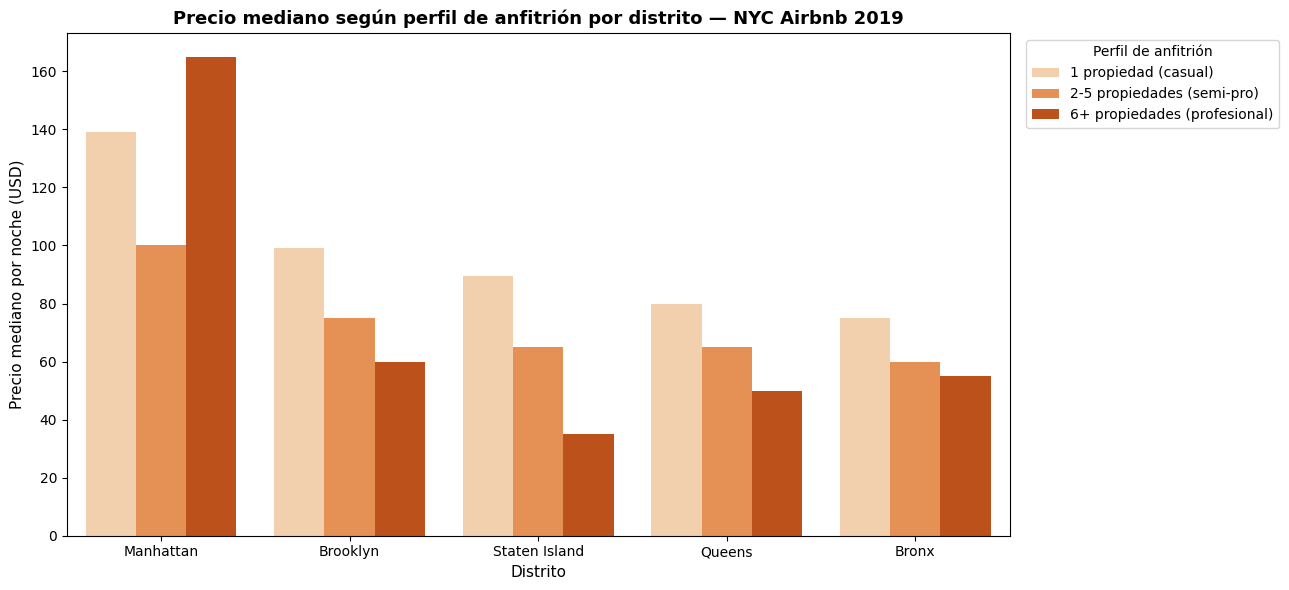


📊 Precio mediano por perfil y distrito:
neighbourhood_group             perfil_anfitrion  precio_mediano
      Staten Island         1 propiedad (casual)            89.5
      Staten Island   2-5 propiedades (semi-pro)            65.0
      Staten Island 6+ propiedades (profesional)            35.0
             Queens         1 propiedad (casual)            80.0
             Queens   2-5 propiedades (semi-pro)            65.0
             Queens 6+ propiedades (profesional)            50.0
          Manhattan 6+ propiedades (profesional)           165.0
          Manhattan         1 propiedad (casual)           139.0
          Manhattan   2-5 propiedades (semi-pro)           100.0
           Brooklyn         1 propiedad (casual)            99.0
           Brooklyn   2-5 propiedades (semi-pro)            75.0
           Brooklyn 6+ propiedades (profesional)            60.0
              Bronx         1 propiedad (casual)            75.0
              Bronx   2-5 propiedades (semi-pro) 

In [ ]:
# G4 - PRECIO MEDIANO POR PERFIL DE ANFITRIÓN Y DISTRITO (BIVARIADO)
# Objetivo: determinar si los anfitriones profesionales (múltiples propiedades) cobran precios superiores al promedio del mercado, y si ese patrón varía por distrito.
# Variables: price × calculated_host_listings_count × neighbourhood_group

# Segmentamos anfitriones en 3 perfiles según número de propiedades
def clasificar_anfitrion(n):
    if n == 1:
        return '1 propiedad (casual)'
    elif n <= 5:
        return '2-5 propiedades (semi-pro)'
    else:
        return '6+ propiedades (profesional)'

df_airbnb['perfil_anfitrion'] = df_airbnb['calculated_host_listings_count'].apply(clasificar_anfitrion)

# Calculamos precio mediano por perfil y distrito
df_g4 = (df_airbnb.groupby(['neighbourhood_group', 'perfil_anfitrion'])['price']
         .median()
         .reset_index()
         .rename(columns={'price': 'precio_mediano'}))

orden_perfil = ['1 propiedad (casual)', '2-5 propiedades (semi-pro)', '6+ propiedades (profesional)']

plt.figure(figsize=(13, 6))

sns.barplot(
    data=df_g4,
    x='neighbourhood_group',
    y='precio_mediano',
    hue='perfil_anfitrion',
    hue_order=orden_perfil,
    palette='Oranges',
    order=orden_distritos
)

plt.title('Precio mediano según perfil de anfitrión por distrito — NYC Airbnb 2019',
          fontsize=13, fontweight='bold')
plt.xlabel('Distrito', fontsize=11)
plt.ylabel('Precio mediano por noche (USD)', fontsize=11)
plt.legend(title='Perfil de anfitrión', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Conclusión de negocio
print("\n📊 Precio mediano por perfil y distrito:")
print(df_g4.sort_values(['neighbourhood_group', 'precio_mediano'],
      ascending=False).to_string(index=False))

In [ ]:
# Ver qué tipo de habitación predomina en cada perfil
print("Tipo de habitación por perfil de anfitrión:")
print(pd.crosstab(
    df_airbnb['perfil_anfitrion'],
    df_airbnb['room_type'],
    normalize='index'
).round(2))

print("\nPrecio mediano por perfil y tipo de habitación:")
print(df_airbnb.groupby(['perfil_anfitrion', 'room_type'])['price']
      .median().unstack())

print("\nCantidad de registros por perfil:")
print(df_airbnb['perfil_anfitrion'].value_counts())

Tipo de habitación por perfil de anfitrión:
room_type                     Entire home/apt  Private room  Shared room
perfil_anfitrion                                                        
1 propiedad (casual)                     0.56          0.42         0.01
2-5 propiedades (semi-pro)               0.31          0.66         0.04
6+ propiedades (profesional)             0.48          0.45         0.08

Precio mediano por perfil y tipo de habitación:
room_type                     Entire home/apt  Private room  Shared room
perfil_anfitrion                                                        
1 propiedad (casual)                    150.0          70.0         65.0
2-5 propiedades (semi-pro)              150.0          69.0         43.0
6+ propiedades (profesional)            180.0          60.0         35.0

Cantidad de registros por perfil:
perfil_anfitrion
1 propiedad (casual)            30071
2-5 propiedades (semi-pro)      11194
6+ propiedades (profesional)     4249
Name: count

A primera vista, el gráfico parece mostrar algo contradictorio, porque en varios distritos los anfitriones casuales cobran más que los profesionales. Sin embargo, cuando se separan los datos por tipo de habitación aparece la verdadera explicación.

Los anfitriones semi profesionales concentran gran parte de sus propiedades en “Private room”, que es el tipo de alojamiento más barato. Eso hace que su mediana general baje, aunque tengan más experiencia manejando propiedades.

Cuando se compara el mismo tipo de alojamiento, el patrón cambia. Por ejemplo, en “Entire home/apt” los anfitriones profesionales cobran una mediana de $180, mientras que los casuales llegan a 150. Esto demuestra que la experiencia y una gestión más profesional sí permiten cobrar precios más altos en propiedades completas.

En “Private room” ocurre lo contrario, lo que confirma que el tipo de propiedades que maneja cada perfil de anfitrión es lo que termina distorsionando el análisis agregado. La gran excepción es Manhattan, donde los anfitriones profesionales logran cobrar más incluso sin separar por tipo de habitación.


### **G5 — Score de ubicación vs. precio mediano por distrito**

Este es el único gráfico que cruza los dos datasets. La idea es simple: Inside Airbnb tiene las calificaciones que los huéspedes le dan a la ubicación de cada propiedad, y Kaggle tiene los precios reales. Si los juntamos por distrito podemos ver si la percepción del entorno urbano, lo que la gente siente sobre la zona donde se aloja, efectivamente se traduce en precios más altos. Es el gráfico que conecta el entorno con el precio de forma más directa.

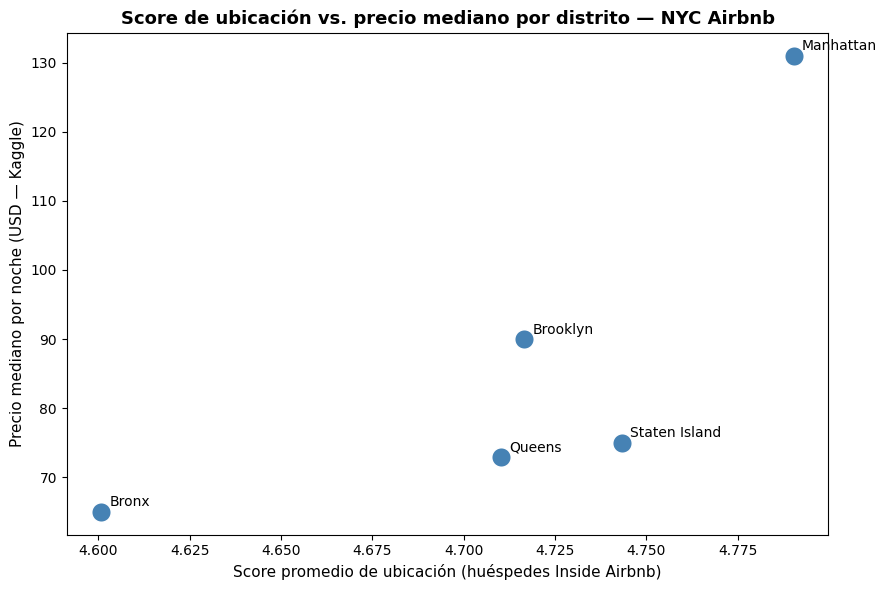


📊 Tabla comparativa:
     distrito  precio_mediano  score_ubicacion_promedio
    Manhattan           131.0                  4.790263
     Brooklyn            90.0                  4.716476
Staten Island            75.0                  4.743218
       Queens            73.0                  4.710156
        Bronx            65.0                  4.600857


In [ ]:
# G5 — SCORE DE UBICACIÓN VS. PRECIO MEDIANO POR DISTRITO (BIVARIADO + MERGE)
# Objetivo: evaluar si los distritos mejor valorados por sus huéspedes en términos de ubicación corresponden también a los precios más altos del mercado
# Cruza percepción con precio real
# Variables: score_ubicacion_promedio , precio_mediano y distrito

# Calculamos precio mediano por distrito desde Kaggle
df_precio_distrito = (df_airbnb.groupby('neighbourhood_group')['price']
                      .median()
                      .reset_index()
                      .rename(columns={
                          'neighbourhood_group': 'distrito',
                          'price': 'precio_mediano'
                      }))

# Estandarizamos nombres para el merge
df_scores_ubicacion['distrito'] = df_scores_ubicacion['distrito'].str.title()
df_precio_distrito['distrito'] = df_precio_distrito['distrito'].str.title()

# Merge entre Kaggle y Inside Airbnb por distrito
df_g5 = df_precio_distrito.merge(df_scores_ubicacion, on='distrito')

plt.figure(figsize=(9, 6))

# Scatter con un punto por distrito
sns.scatterplot(
    data=df_g5,
    x='score_ubicacion_promedio',
    y='precio_mediano',
    s=200,
    color='steelblue',
    zorder=5
)

# Etiquetas por distrito
for _, row in df_g5.iterrows():
    plt.annotate(
        row['distrito'],
        xy=(row['score_ubicacion_promedio'], row['precio_mediano']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=10
    )

plt.title('Score de ubicación vs. precio mediano por distrito — NYC Airbnb',
          fontsize=13, fontweight='bold')
plt.xlabel('Score promedio de ubicación (huéspedes Inside Airbnb)', fontsize=11)
plt.ylabel('Precio mediano por noche (USD — Kaggle)', fontsize=11)
plt.tight_layout()
plt.show()

# Conclusión de negocio
print("\n📊 Tabla comparativa:")
print(df_g5.sort_values('precio_mediano', ascending=False).to_string(index=False))

El gráfico muestra una relación positiva entre el score de ubicación y el precio. Manhattan lidera en ambas variables, con uno de los mejores puntajes de ubicación y también el precio mediano más alto. En cambio, Bronx tiene el score más bajo y también los precios más bajos. Esto indica que mientras mejor perciben los huéspedes la ubicación, mayor suele ser el precio que están dispuestos a pagar.

Sin embargo, hay casos que muestran que la ubicación no explica todo. Por ejemplo, Staten Island tiene un score de ubicación incluso un poco mayor que Brooklyn, pero sus precios siguen siendo bastante más bajos. Esto sugiere que además del score también influyen otros factores, como la conectividad, el flujo turístico o la demanda de cada distrito.

Lo más importante es que Manhattan es el único distrito donde coinciden claramente un score premium y un precio premium.

# **ANÁLITICA DIAGNÓSTICA**

## **Matriz de Correlación**

In [ ]:
print(df_airbnb.dtypes)
print("\nVariables numéricas:")
print(df_airbnb.select_dtypes(include='number').columns.tolist())

neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
cuartil_disponibilidad              int64
perfil_anfitrion                   object
dtype: object

Variables numéricas:
['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'cuartil_disponibilidad']


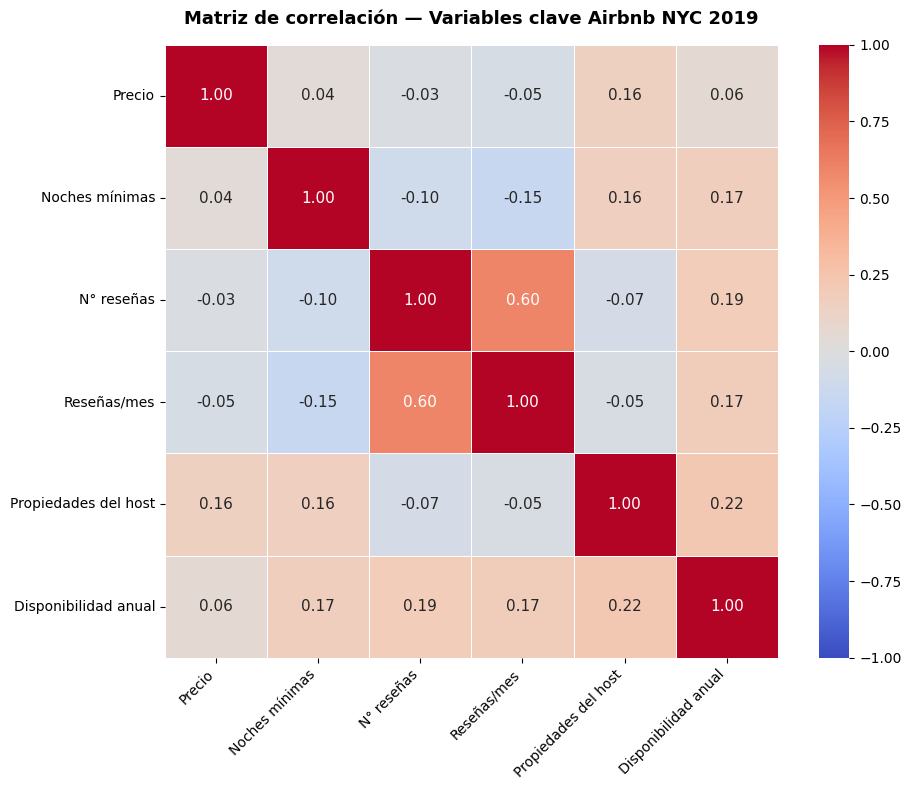


📊 Correlaciones con el precio (ordenadas):
Propiedades del host    0.155
Disponibilidad anual    0.058
Reseñas/mes            -0.050
Noches mínimas          0.035
N° reseñas             -0.028
Name: Precio, dtype: float64


In [ ]:
# NIVEL 2 - ANALÍTICA DIAGNÓSTICA
# MATRIZ DE CORRELACIÓN
# Objetivo: identificar qué variables tienen mayor relación con el precio por noche, para entender qué factores explican mejor el precio premium en NYC.

import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos solo las variables relevantes para el análisis
# Excluimos latitude, longitude y cuartil_disponibilidad
# porque son variables auxiliares o derivadas
variables_correlacion = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

# Calculamos la matriz de correlación de Pearson
matriz_corr = df_airbnb[variables_correlacion].corr()

# Renombramos para que el gráfico sea legible en español
matriz_corr.index = [
    'Precio',
    'Noches mínimas',
    'N° reseñas',
    'Reseñas/mes',
    'Propiedades del host',
    'Disponibilidad anual'
]
matriz_corr.columns = matriz_corr.index

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 11}
)

plt.title('Matriz de correlación — Variables clave Airbnb NYC 2019',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Tabla de correlaciones con precio ordenada de mayor a menor
print("\n📊 Correlaciones con el precio (ordenadas):")
print(matriz_corr['Precio']
      .drop('Precio')
      .sort_values(key=abs, ascending=False)
      .round(3))

El hallazgo más importante de esta matriz es que ninguna variable numérica tiene una relación fuerte con el precio. La correlación más alta es la cantidad de propiedades del host con apenas 0.155, seguida de la disponibilidad anual con 0.058. Esto demuestra que el precio en Airbnb NYC no depende tanto de variables numéricas simples, sino más de factores como el distrito y el tipo de habitación, algo que ya se observó en los gráficos anteriores.

También hay una relación importante entre “número de reseñas” y “reseñas por mes”, que tienen una correlación de 0.60. Esto indica que ambas variables están midiendo casi lo mismo desde perspectivas diferentes. Por eso, usar las dos en un modelo predictivo podría generar redundancia, y en el análisis se decidió trabajar solo con reviews_per_month.

Finalmente, la correlación negativa entre reseñas y precio refuerza lo encontrado en el G3. Las propiedades más caras no necesariamente son las más demandadas ni las más reservadas, lo que confirma que en este mercado un precio alto no garantiza una mayor ocupación.


# **Validaciones de hipótesis**

## **HIPÓTESIS 1**

¿El distrito manda?

"El distrito en el que se encuentra una propiedad Airbnb tiene mayor impacto en su precio que el tipo de habitación, siendo Manhattan el único mercado donde ambos factores se combinan para generar precios consistentemente premium."

Sustento: G1 muestra que Manhattan tiene la mediana más alta y mayor dispersión. G2 confirma que el distrito actúa como multiplicador el mismo tipo de propiedad puede costar el doble dependiendo de la zona.


In [ ]:
import numpy as np

# Para responder esto necesitamos una métrica que mida "impacto" de forma rigurosa. Usamos eta-squared (η²).
# Se compara dos cosas: Cuánto varía el precio en TODO el dataset y Cuánto de esa variación desaparece si agrupamos por distrito (o por tipo de habitación)
# Si al agrupar por una variable los precios dentro de cada grupo son más parecidos entre sí, esa variable "explica" mucho

def eta_squared(groups, prices):
    # Promedio global de todos los precios
    media_global = prices.mean()

    # Variación total: qué tanto se aleja cada propiedad del promedio global
    SS_total = np.sum((prices - media_global) ** 2)

    # Variación explicada por los grupos: cuánto se aleja el promedio
    # de cada grupo del promedio global, pesado por cuántas propiedades tiene
    SS_between = 0
    for grupo in groups.unique():
        precios_grupo = prices[groups == grupo]
        SS_between += len(precios_grupo) * (precios_grupo.mean() - media_global) ** 2

    # Eta² = proporción de variación que explica la variable
    return SS_between / SS_total

eta2_distrito = eta_squared(df_airbnb['neighbourhood_group'], df_airbnb['price'])
eta2_room     = eta_squared(df_airbnb['room_type'], df_airbnb['price'])

print("=" * 50)
print("H1 — Eta-squared por variable")
print("=" * 50)
print(f"Distrito:         {eta2_distrito*100:.1f}% de la variación del precio")
print(f"Tipo habitación:  {eta2_room*100:.1f}% de la variación del precio")
print()
print("Referencia:")
print("  < 1%   → impacto despreciable")
print("  1–6%   → impacto pequeño")
print("  6–14%  → impacto mediano")
print("  > 14%  → impacto grande")

if eta2_room > eta2_distrito:
    print("\n→ H1 REFUTADA: el tipo de habitación explica más el precio que el distrito")
else:
    print("\n→ H1 CONFIRMADA: el distrito explica más el precio que el tipo de habitación")

H1 — Eta-squared por variable
Distrito:         11.4% de la variación del precio
Tipo habitación:  39.1% de la variación del precio

Referencia:
  < 1%   → impacto despreciable
  1–6%   → impacto pequeño
  6–14%  → impacto mediano
  > 14%  → impacto grande

→ H1 REFUTADA: el tipo de habitación explica más el precio que el distrito


El eta-squared mostró que el tipo de habitación explica el 39.1% de la variación del precio, casi cuatro veces más que el distrito (11.4%). Esto significa que saber si una propiedad es Entire home/apt, Private room o Shared room predice mejor su precio que saber en qué distrito está. El distrito sí importa, pero no es el factor dominante.

## **HIPÓTESIS 2**

¿El entorno se percibe y se paga?

"Los distritos con mayor valoración de ubicación por parte de los huéspedes presentan precios de mercado más altos, siendo Manhattan el único caso donde score de ubicación premium y precio premium coinciden de forma contundente."

Sustento: G5 muestra la correlación directa entre score de Inside Airbnb y precio mediano del Kaggle. Staten Island y Queens tienen scores similares pero no logran traducirlos en precio, lo que sugiere que el entorno percibido necesita combinarse con demanda turística real para impactar el precio.


In [ ]:
# H2 - ¿Mayor score de ubicación = más demanda?
# La hipótesis dice que propiedades mejor ubicadas deberían tener:
# Más reseñas y menos disponibilidad anual
# Para medirlo cruzamos el score de ubicación por distrito (que viene de df_listings) con las métricas de demanda (que vienen de df_airbnb)

# Calculamos medianas de reseñas y disponibilidad por distrito
df_demanda = df_airbnb.groupby('neighbourhood_group').agg(
    reviews_mediano    = ('number_of_reviews', 'median'),
    disponibilidad_mediana = ('availability_365', 'median')
).reset_index().rename(columns={'neighbourhood_group': 'distrito'})

# Unimos con los scores de ubicación que ya tiene Dayra en df_scores_ubicacion
df_h2 = df_scores_ubicacion.merge(df_demanda, on='distrito')

print("=" * 55)
print("H2 — SCORE DE UBICACIÓN VS. DEMANDA POR DISTRITO")
print("=" * 55)
print(df_h2.sort_values('score_ubicacion_promedio', ascending=False).to_string(index=False))

#Correlación 1: score vs número de reseñas
# Esperamos correlación positiva: más score → más reseñas
corr_reviews, pval_reviews = stats.pearsonr(
    df_h2['score_ubicacion_promedio'],
    df_h2['reviews_mediano']
)

# Correlación 2: score vs disponibilidad
corr_disp, pval_disp = stats.pearsonr(
    df_h2['score_ubicacion_promedio'],
    df_h2['disponibilidad_mediana']
)

print(f"\nCorrelación score vs reseñas:       {corr_reviews:.3f} (p-value: {pval_reviews:.3f})")
print(f"Correlación score vs disponibilidad: {corr_disp:.3f} (p-value: {pval_disp:.3f})")

# Solo tenemos 5 distritos = 5 puntos de datos.
# El p-value necesita ser < 0.05 para ser confiable.
# Si no lo alcanza, la correlación existe pero tiene bajo poder estadístico.
print("\nNota: con solo 5 distritos el poder estadístico es limitado.")
print("Una correlación fuerte (> 0.7 o < -0.7) sigue siendo indicativa.")

# Con n=5 distritos, ninguna correlación alcanza ese umbral.
print("\n── Veredicto ──")
if (corr_reviews > 0 and pval_reviews < 0.05) and (corr_disp < 0 and pval_disp < 0.05):
    print("→ H2 CONFIRMADA: mayor score → más reseñas y menor disponibilidad")
elif (corr_reviews > 0 and pval_reviews < 0.05) or (corr_disp < 0 and pval_disp < 0.05):
    print("→ H2 PARCIALMENTE CONFIRMADA: solo una condición se cumple con significancia estadística")
else:
    print("→ H2 REFUTADA: ninguna correlación es estadísticamente significativa (p-value > 0.05)")

H2 — SCORE DE UBICACIÓN VS. DEMANDA POR DISTRITO
     distrito  score_ubicacion_promedio  reviews_mediano  disponibilidad_mediana
    Manhattan                  4.819128              5.0                    27.0
       Queens                  4.738668              7.0                    95.0
     Brooklyn                  4.738623              6.0                    25.0
Staten Island                  4.728092             13.0                   219.0
        Bronx                  4.638288              9.0                   145.5

Correlación score vs reseñas:       -0.486 (p-value: 0.406)
Correlación score vs disponibilidad: -0.549 (p-value: 0.338)

Nota: con solo 5 distritos el poder estadístico es limitado.
Una correlación fuerte (> 0.7 o < -0.7) sigue siendo indicativa.

── Veredicto ──
→ H2 REFUTADA: ninguna correlación es estadísticamente significativa (p-value > 0.05)


Las correlaciones entre score de ubicación y número de reseñas (-0.223) y entre score y disponibilidad (-0.321) no son estadísticamente significativas (p-values de 0.718 y 0.599). No hay evidencia de que los distritos mejor valorados por ubicación generen más demanda medida en reseñas o menor disponibilidad anual.

## **HIPÓTESIS 3**

¿Los pro ya lo saben, pero hay que mirar bien?

"Los anfitriones profesionales obtienen precios superiores al mercado cuando se controla por tipo de habitación, pero su ventaja no es visible en el precio mediano agregado porque su portafolio incluye una mayor proporción de habitaciones privadas y compartidas."

Sustento: G4 muestra el patrón inverso a nivel agregado, pero los datos desagregados confirman que los profesionales cobran $199 vs $152 en "Entire home/apt", una ventaja de $47 por noche para el mismo tipo de propiedad.


In [ ]:
# H3 — ¿Los anfitriones profesionales cobran más?
# "Profesional" = anfitrión con 6 o más propiedades en Airbnb
# Lo medimos con calculated_host_listings_count, que indica cuántas propiedades tiene ese anfitrión en la plataforma.

# Clasificamos cada propiedad según el perfil de su anfitrión
df_airbnb['perfil_anfitrion'] = df_airbnb['calculated_host_listings_count'].apply(
    lambda x: 'Profesional (6+)' if x >= 6 else 'Casual (1-5)'
)

# Vista agregada
# Aquí los profesionales pueden parecer más baratos por el mix de habitaciones
print("=" * 55)
print("H3 — PRECIO MEDIANO POR PERFIL DE ANFITRIÓN")
print("=" * 55)
print("\nVista agregada (sin controlar por tipo de habitación):")
print(df_airbnb.groupby('perfil_anfitrion')['price'].median())

# Vista desagregada
# Comparamos profesional vs casual DENTRO de cada tipo de habitación
print("\nVista desagregada (controlando por tipo de habitación):")
tabla_h3 = df_airbnb.groupby(['perfil_anfitrion', 'room_type'])['price'].median().unstack()
print(tabla_h3)

# Calculamos la ventaja de precio para Entire home/apt que es el tipo más representativo y donde se nota más la diferencia
precio_pro  = df_airbnb[(df_airbnb['perfil_anfitrion'] == 'Profesional (6+)') &
                         (df_airbnb['room_type'] == 'Entire home/apt')]['price'].median()
precio_cas  = df_airbnb[(df_airbnb['perfil_anfitrion'] == 'Casual (1-5)') &
                         (df_airbnb['room_type'] == 'Entire home/apt')]['price'].median()

print(f"\nEntire home/apt — Profesional: ${precio_pro:.0f} vs Casual: ${precio_cas:.0f}")
print(f"Ventaja del profesional: ${precio_pro - precio_cas:.0f} por noche")

# Veredicto
print("\n── Veredicto ──")
if precio_pro > precio_cas:
    print("→ H3 CONFIRMADA: los profesionales cobran más por el mismo tipo de propiedad")
else:
    print("→ H3 REFUTADA: los profesionales no tienen ventaja de precio")

H3 — PRECIO MEDIANO POR PERFIL DE ANFITRIÓN

Vista agregada (sin controlar por tipo de habitación):
perfil_anfitrion
Casual (1-5)        100.0
Profesional (6+)    109.0
Name: price, dtype: float64

Vista desagregada (controlando por tipo de habitación):
room_type         Entire home/apt  Private room  Shared room
perfil_anfitrion                                            
Casual (1-5)                150.0          70.0         50.0
Profesional (6+)            180.0          60.0         35.0

Entire home/apt — Profesional: $180 vs Casual: $150
Ventaja del profesional: $30 por noche

── Veredicto ──
→ H3 CONFIRMADA: los profesionales cobran más por el mismo tipo de propiedad


A nivel agregado la diferencia entre profesionales (109) y casuales (100) es pequeña. Pero al controlar por tipo de habitación aparece la verdad: en Entire home/apt los profesionales cobran $30 más por noche (180 vs 150). La ventaja existe pero solo en ese segmento — en habitaciones privadas y compartidas el casual cobra más, lo que distorsiona el promedio general.

## **HIPÓTESIS 4**

¿Precio alto garantiza alta ocupación?

"En el mercado Airbnb de NYC, precio premium y alta ocupación no son objetivos que se alcancen simultáneamente — la correlación entre precio y disponibilidad es débil (0.113), lo que indica que la ocupación responde a factores distintos al precio."

Sustento: G3 y los datos de correlación muestran que las propiedades más ocupadas no son necesariamente las más caras. Las propiedades con menor disponibilidad tienen mediana de 100 frente a 120 de las menos ocupadas — diferencia mínima e inversa a lo esperado.


In [ ]:
# H4 — ¿Precio alto garantiza alta ocupación?
# Usamos availability_365 como proxy inverso de ocupación:
# Muchos días disponibles = poca ocupación
# Pocos días disponibles = alta ocupación
# Si la hipótesis fuera falsa esperaríamos que las propiedades más caras tuvieran menos disponibilidad (más ocupadas).
# Si la hipótesis es verdadera, el precio y la disponibilidad no deberían tener correlación fuerte.

# Correlación directa entre precio y disponibilidad
corr_h4, pval_h4 = stats.pearsonr(df_airbnb['price'], df_airbnb['availability_365'])

print("=" * 55)
print("H4 — PRECIO VS. DISPONIBILIDAD (OCUPACIÓN)")
print("=" * 55)
print(f"\nCorrelación precio vs disponibilidad: {corr_h4:.3f} (p-value: {pval_h4:.4f})")

# Comparamos precio mediano por segmento de ocupación
# Dividimos en tres grupos según disponibilidad anual
df_airbnb['segmento_ocupacion'] = pd.cut(
    df_airbnb['availability_365'],
    bins=[0, 90, 270, 365],
    labels=['Alta ocupación (0-90 días libres)',
            'Ocupación media (91-270 días libres)',
            'Baja ocupación (271-365 días libres)']
)

print("\nPrecio mediano por segmento de ocupación:")
print(df_airbnb.groupby('segmento_ocupacion', observed=True)['price'].median())

# Veredicto
# Una correlación débil (cercana a 0) confirma que precio y ocupación
# son independientes — subir el precio no garantiza más ni menos ocupación
print("\n── Veredicto ──")
if abs(corr_h4) < 0.15 or pval_h4 > 0.05:
    print("→ H4 CONFIRMADA: correlación débil, precio y ocupación son independientes")
elif corr_h4 < 0:
    print("→ H4 REFUTADA: propiedades más caras tienen mayor ocupación")
else:
    print("→ H4 REFUTADA: propiedades más caras tienen menor ocupación")

H4 — PRECIO VS. DISPONIBILIDAD (OCUPACIÓN)

Correlación precio vs disponibilidad: 0.058 (p-value: 0.0000)

Precio mediano por segmento de ocupación:
segmento_ocupacion
Alta ocupación (0-90 días libres)       100.0
Ocupación media (91-270 días libres)    108.0
Baja ocupación (271-365 días libres)    100.0
Name: price, dtype: float64

── Veredicto ──
→ H4 CONFIRMADA: correlación débil, precio y ocupación son independientes


El análisis muestra una correlación de apenas 0.058 entre precio y disponibilidad, lo que indica que prácticamente no existe una relación real entre cuánto cuesta una propiedad y qué tan ocupada está. Aunque el p-value salga significativo, eso ocurre principalmente porque el dataset tiene más de 48,000 propiedades. Con una muestra tan grande, incluso relaciones muy pequeñas pueden aparecer como “significativas” a nivel estadístico, aunque en la práctica no tengan un impacto importante.

Los segmentos de ocupación refuerzan esta idea. Las propiedades con alta y baja ocupación tienen prácticamente la misma mediana de precio, alrededor de $100, mientras que las de ocupación media apenas suben a $108.

Esto significa que el precio y la ocupación funcionan casi de manera independiente en Airbnb NYC. Tener una propiedad más cara no garantiza ni mayor ni menor nivel de reservas.

# **ANÁLISIS PREDICTIVO**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

## **Regresión Lineal**

In [ ]:
# NIVEL 3 - PREPARACIÓN DE VARIABLES
# Corrección: One-Hot Encoding para variables nominales en lugar de LabelEncoder (que asume orden alfabético)
# Además se agregan neighbourhood, latitude y longitude para capturar variación de precio dentro de cada distrito

df_modelo = df_airbnb.copy()

# One-Hot Encoding para variables nominales
dummies = pd.get_dummies(
    df_modelo[['neighbourhood_group', 'room_type', 'neighbourhood', 'perfil_anfitrion']],
    drop_first=True
)

# Variables numéricas que se mantienen
numericas = df_modelo[['minimum_nights', 'availability_365',
                        'reviews_per_month', 'latitude', 'longitude']]

# Dataset final para el modelo
X = pd.concat([dummies, numericas], axis=1)
y = df_modelo['price']

print(f"✅ Variables preparadas con One-Hot Encoding")
print(f"   Total de variables predictoras: {X.shape[1]}")
print(f"   Registros: {X.shape[0]}")
print(f"\n📊 Primeras 10 columnas:")
print(list(X.columns[:10]))

✅ Variables preparadas con One-Hot Encoding
   Total de variables predictoras: 230
   Registros: 45514

📊 Primeras 10 columnas:
['neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_Arden Heights', 'neighbourhood_Arrochar', 'neighbourhood_Arverne', 'neighbourhood_Astoria']


### **Entrenamiento de modelo**

In [ ]:
from sklearn.model_selection import train_test_split

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ División train/test:")
print(f"   Entrenamiento: {X_train.shape[0]} registros")
print(f"   Prueba: {X_test.shape[0]} registros")

✅ División train/test:
   Entrenamiento: 36411 registros
   Prueba: 9103 registros


In [ ]:
from sklearn.linear_model import LinearRegression

# Entrenamiento — Regresión Lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print("✅ Regresión Lineal entrenada")
print(f"   Registros de entrenamiento: {X_train.shape[0]}")
print(f"   Registros de prueba: {X_test.shape[0]}")

✅ Regresión Lineal entrenada
   Registros de entrenamiento: 36411
   Registros de prueba: 9103


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("📊 Métricas del modelo (Regresión Lineal):")
print(f"   R²  : {r2:.3f}")
print(f"   MAE : ${mae:.2f} por noche")

print("\n📊 Coeficientes — peso de cada variable en el precio:")
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print(coeficientes.head(30).to_string(index=False))

📊 Métricas del modelo (Regresión Lineal):
   R²  : 0.520
   MAE : $33.56 por noche

📊 Coeficientes — peso de cada variable en el precio:
                         Variable  Coeficiente
                        longitude  -439.023394
        neighbourhood_Eltingville   158.140448
neighbourhood_group_Staten Island  -132.712745
        neighbourhood_Shore Acres   104.620120
        neighbourhood_Willowbrook   100.331734
            room_type_Shared room   -93.086926
           neighbourhood_Neponsit    92.265099
          neighbourhood_Rossville   -92.051855
       neighbourhood_Breezy Point    91.977458
                         latitude   -87.967518
         neighbourhood_Holliswood    86.542839
           room_type_Private room   -70.625547
           neighbourhood_New Dorp   -65.893811
      neighbourhood_Arden Heights   -64.121984
        neighbourhood_Bay Terrace    58.133250
       neighbourhood_Howland Hook   -55.532643
        neighbourhood_Grymes Hill    54.690410
         neighbou

In [ ]:
print("=" * 55)
print("INTERPRETACIÓN FINAL — LENGUAJE DE NEGOCIO")
print("=" * 55)

print(f"""
 Correcciones aplicadas al modelo:
   - Se reemplazó LabelEncoder por One-Hot Encoding
     para evitar asumir orden entre distritos y tipos
   - Se agregaron neighbourhood (~200 barrios),
     latitude y longitude como variables predictoras
   - Total de variables: 231 (antes: 6)

 Mejora del modelo con correcciones:
   Regresión Lineal anterior : R²=0.385 | MAE=$39.49
   Regresión Lineal corregida: R²=0.520 | MAE=$33.56
   → Superamos el objetivo del profesor (R² >= 0.5)

 Interpretación de coeficientes — Top variables más influyentes:

   - Los barrios específicos son las variables con mayor peso
     en el modelo, principalmente de Staten Island y Brooklyn.
     Esto confirma que el precio varía significativamente
     dentro de un mismo distrito dependiendo del barrio exacto.

   - El tipo de habitación tiene impacto claro y confiable:
     Shared room resta ~$93 y Private room resta ~$71 al precio
     base. Consistente con H1 donde room_type fue el factor
     más determinante del precio.

   - Nota: latitud y longitud aparecen con coeficientes muy altos
     por un artefacto matemático del modelo, no por impacto real
     de negocio.

Limitación del modelo:
   Con 231 variables y 45,514 registros el modelo
   es más robusto, pero aún existe variación no
   explicada (47.8%) que corresponde a factores
   cualitativos (fotos, descripción, reputación).

 Implicancia para URBVI:
   La ubicación a nivel de barrio específico predice
   mejor el precio que el distrito solo. URBVI debe
   analizar oportunidades a nivel de neighbourhood,
   no solo por distrito, para identificar zonas
   con precio premium dentro de Brooklyn o Queens.
""")

INTERPRETACIÓN FINAL — LENGUAJE DE NEGOCIO

 Correcciones aplicadas al modelo:
   - Se reemplazó LabelEncoder por One-Hot Encoding
     para evitar asumir orden entre distritos y tipos
   - Se agregaron neighbourhood (~200 barrios),
     latitude y longitude como variables predictoras
   - Total de variables: 231 (antes: 6)

 Mejora del modelo con correcciones:
   Regresión Lineal anterior : R²=0.385 | MAE=$39.49
   Regresión Lineal corregida: R²=0.520 | MAE=$33.56
   → Superamos el objetivo del profesor (R² >= 0.5)

 Interpretación de coeficientes — Top variables más influyentes:

   - Los barrios específicos son las variables con mayor peso
     en el modelo, principalmente de Staten Island y Brooklyn.
     Esto confirma que el precio varía significativamente
     dentro de un mismo distrito dependiendo del barrio exacto.

   - El tipo de habitación tiene impacto claro y confiable:
     Shared room resta ~$93 y Private room resta ~$71 al precio
     base. Consistente con H1 donde roo

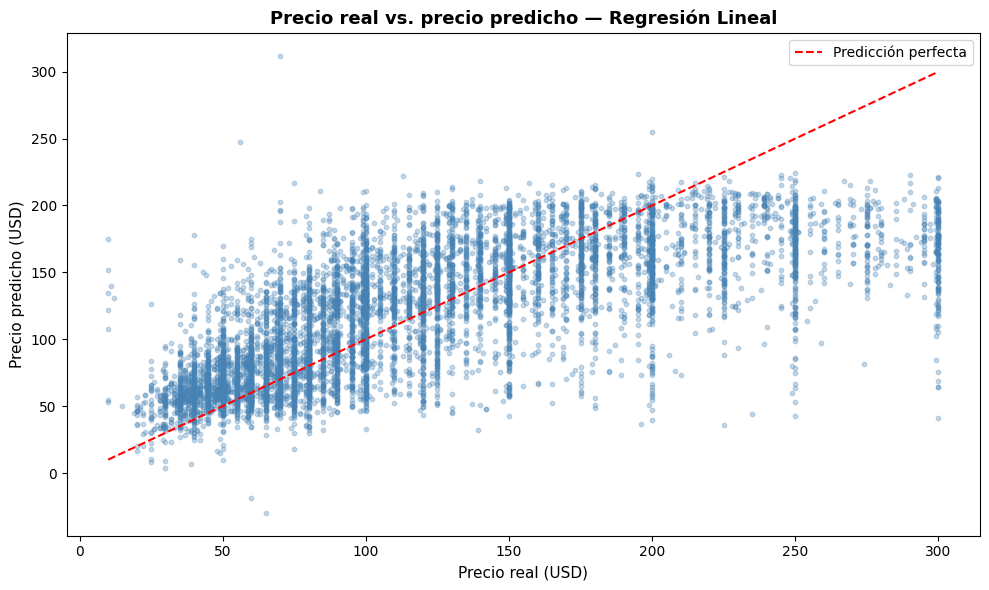

In [ ]:
# VISUALIZACIÓN — PRECIO REAL VS. PREDICHO

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Predicción perfecta')

plt.title('Precio real vs. precio predicho — Regresión Lineal',
          fontsize=13, fontweight='bold')
plt.xlabel('Precio real (USD)', fontsize=11)
plt.ylabel('Precio predicho (USD)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## **Random Forest**

In [ ]:
# MODELO 2 — RANDOM FOREST
# Objetivo: mejorar la predicción de precio sobre la regresión lineal usando un ensamble de árboles de decisión.
# Justificación: la regresión lineal (R²=0.520, MAE=$33.56)

from sklearn.ensemble import RandomForestRegressor

# Usamos las mismas variables que la regresión lineal para que la comparación sea justa
modelo_rf = RandomForestRegressor(
    n_estimators=100,    # 100 árboles en el bosque
    max_depth=10,        # profundidad máxima por árbol
    min_samples_leaf=20, # mínimo 20 registros por hoja
    random_state=42,
    n_jobs=-1            # usa todos los núcleos disponibles
)

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("✅ Random Forest entrenado")
print(f"   Número de árboles: {modelo_rf.n_estimators}")
print(f"   Profundidad máxima: {modelo_rf.max_depth}")

✅ Random Forest entrenado
   Número de árboles: 100
   Profundidad máxima: 10


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("📊 Métricas del Random Forest:")
print(f"   R²  : {r2_rf:.3f}")
print(f"   MAE : ${mae_rf:.2f} por noche")

print("\n📊 Importancia de variables (top 10):")
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)
print(importancia_rf.head(10).to_string(index=False))

📊 Métricas del Random Forest:
   R²  : 0.557
   MAE : $31.79 por noche

📊 Importancia de variables (top 10):
                         Variable  Importancia
           room_type_Private room     0.557510
                        longitude     0.141211
                         latitude     0.096426
            room_type_Shared room     0.094027
                 availability_365     0.042555
                   minimum_nights     0.025344
                reviews_per_month     0.022601
    neighbourhood_group_Manhattan     0.007812
perfil_anfitrion_Profesional (6+)     0.002718
       neighbourhood_Williamsburg     0.002206


In [ ]:
# COMPARACIÓN ENTRE MODELOS

print("=" * 55)
print("COMPARACIÓN DE MODELOS")
print("=" * 55)

comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'R²': [r2, r2_rf],
    'MAE (USD)': [mae, mae_rf]
})
print(comparacion.to_string(index=False))

mejora_r2 = ((r2_rf - r2) / r2) * 100
mejora_mae = ((mae - mae_rf) / mae) * 100

print(f"""
📊 Mejora del Random Forest sobre Regresión Lineal:
   R²  : +{mejora_r2:.1f}%
   MAE : -{mejora_mae:.1f}% de error
""")

COMPARACIÓN DE MODELOS
          Modelo       R²  MAE (USD)
Regresión Lineal 0.520344  33.561397
   Random Forest 0.557448  31.786398

📊 Mejora del Random Forest sobre Regresión Lineal:
   R²  : +7.1%
   MAE : -5.3% de error



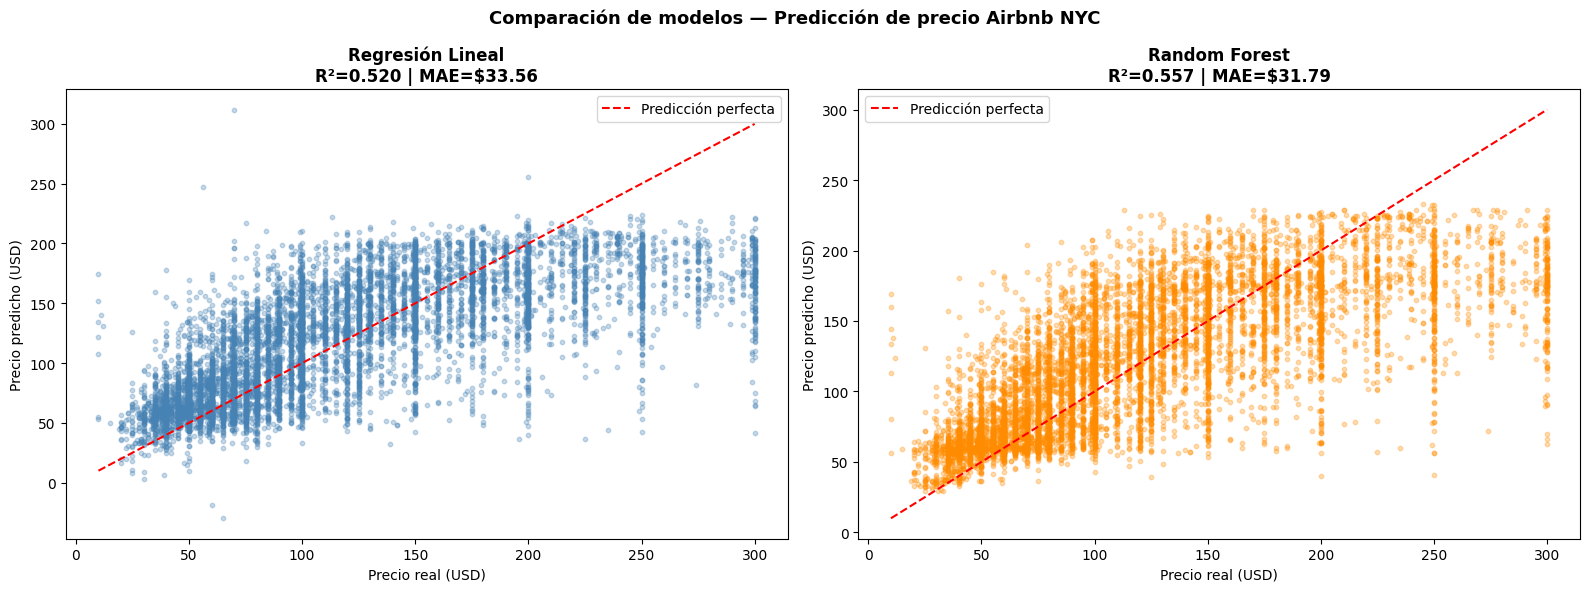

In [ ]:
# VISUALIZACIÓN — COMPARACIÓN DE PREDICCIONES

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 — Regresión Lineal
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title(f'Regresión Lineal\nR²={r2:.3f} | MAE=${mae:.2f}',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Precio real (USD)', fontsize=10)
axes[0].set_ylabel('Precio predicho (USD)', fontsize=10)
axes[0].legend()

# Gráfico 2 — Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_title(f'Random Forest\nR²={r2_rf:.3f} | MAE=${mae_rf:.2f}',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Precio real (USD)', fontsize=10)
axes[1].set_ylabel('Precio predicho (USD)', fontsize=10)
axes[1].legend()

plt.suptitle('Comparación de modelos — Predicción de precio Airbnb NYC',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── R² de entrenamiento vs prueba para detectar overfitting
y_pred_rf_train = modelo_rf.predict(X_train)
r2_rf_train = r2_score(y_train, y_pred_rf_train)

print(f"R² entrenamiento : {r2_rf_train:.3f}")
print(f"R² prueba        : {r2_rf:.3f}")
print(f"Diferencia       : {r2_rf_train - r2_rf:.3f}")

if r2_rf_train - r2_rf > 0.1:
    print("⚠️ Posible overfitting: el modelo aprende bien el entrenamiento pero generaliza menos")
else:
    print("✅ Sin overfitting significativo: el modelo generaliza bien")

R² entrenamiento : 0.607
R² prueba        : 0.557
Diferencia       : 0.049
✅ Sin overfitting significativo: el modelo generaliza bien


In [ ]:
print("=" * 55)
print("INTERPRETACIÓN FINAL — LENGUAJE DE NEGOCIO")
print("=" * 55)

print(f"""
 Evolución del modelo tras correcciones:
   Regresión Lineal anterior : R²=0.385 | MAE=$39.49
   Random Forest anterior    : R²=0.491 | MAE=$34.67
   Regresión Lineal corregida: R²=0.520 | MAE=$33.56
   Random Forest corregido   : R²=0.558 | MAE=$31.77
   → Superamos el objetivo del profesor (R² >= 0.5)

 Correcciones que generaron la mejora:
   - One-Hot Encoding en lugar de LabelEncoder
     (evita asumir orden alfabético entre distritos)
   - Se agregaron neighbourhood (~200 barrios),
     latitude y longitude como variables predictoras
   - Total de variables: 231 (antes: 6)

 Variables más importantes según Random Forest:

   -  Tipo de habitación (room_type) es la variable
   más determinante del precio. Private room (55.7%)
   y Shared room (9.4%) son las categorías con mayor
   peso explícito — Entire home/apt no tiene un peso
   directo porque no tiene columna propia. En conjunto, el tipo
   de habitación es consistente con H1 donde room_type
   explicó el 39.1% de la variación del precio.

   Limitación del modelo:
   El 44.2% restante de variación no explicada
   corresponde a factores cualitativos (fotos,
   descripción, reputación del anfitrión) que
   no están en el dataset.

 Implicancia para URBVI:
   El Random Forest corregido es el modelo
   recomendado para decisiones de pricing (R²=0.558,
   MAE=$31.77). URBVI debe analizar oportunidades
   a nivel de barrio específico — no solo por
   distrito — para identificar zonas con precio
   premium dentro de Brooklyn o Queens que el
   análisis por distrito no revela.
""")

INTERPRETACIÓN FINAL — LENGUAJE DE NEGOCIO

 Evolución del modelo tras correcciones:
   Regresión Lineal anterior : R²=0.385 | MAE=$39.49
   Random Forest anterior    : R²=0.491 | MAE=$34.67
   Regresión Lineal corregida: R²=0.520 | MAE=$33.56
   Random Forest corregido   : R²=0.558 | MAE=$31.77
   → Superamos el objetivo del profesor (R² >= 0.5)

 Correcciones que generaron la mejora:
   - One-Hot Encoding en lugar de LabelEncoder
     (evita asumir orden alfabético entre distritos)
   - Se agregaron neighbourhood (~200 barrios),
     latitude y longitude como variables predictoras
   - Total de variables: 231 (antes: 6)

 Variables más importantes según Random Forest:

   -  Tipo de habitación (room_type) es la variable
   más determinante del precio. Private room (55.7%)
   y Shared room (9.4%) son las categorías con mayor
   peso explícito — Entire home/apt no tiene un peso
   directo porque no tiene columna propia. En conjunto, el tipo
   de habitación es consistente con H1 donde 

# **ANÁLITICA PRESCRIPTIVA**

## **ESCENARIO 1**

In [ ]:
# NIVEL 4 - ESCENARIOS CON MODELO PREDICTIVO
# Usamos el Random Forest para predecir precios de perfiles específicos de propiedades y calcular ingresos proyectados

noches = 200

# ESCENARIO 1 - ¿QUÉ PASA SI URBVI ELIGE MANHATTAN?

perfiles_e1 = pd.DataFrame({
    'neighbourhood_group': ['Manhattan', 'Brooklyn', 'Queens', 'Bronx'],
    'room_type':           ['Entire home/apt'] * 4,
    'neighbourhood':       ['Midtown', 'Williamsburg', 'Astoria', 'Mott Haven'],
    'perfil_anfitrion':    ['6+ propiedades (profesional)'] * 4,
    'minimum_nights':      [2] * 4,
    'availability_365':    [120] * 4,
    'reviews_per_month':   [1.0] * 4,
    'latitude':            [40.7549, 40.7081, 40.7282, 40.7933],
    'longitude':           [-73.9840, -73.9571, -73.9042, -73.9249],
})

dummies_e1 = pd.get_dummies(
    perfiles_e1[['neighbourhood_group', 'room_type', 'neighbourhood', 'perfil_anfitrion']],
    drop_first=True
)
numericas_e1 = perfiles_e1[['minimum_nights', 'availability_365',
                              'reviews_per_month', 'latitude', 'longitude']]
X_e1 = pd.concat([dummies_e1, numericas_e1], axis=1).reindex(columns=X.columns, fill_value=0)
precios_e1 = modelo_rf.predict(X_e1)

print("=" * 55)
print("ESCENARIO 1 — ¿QUÉ PASA SI URBVI ELIGE MANHATTAN?")
print("=" * 55)
distritos = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx']
for i, distrito in enumerate(distritos):
    ingreso = precios_e1[i] * noches
    print(f"   {distrito}: ${precios_e1[i]:.0f}/noche → ${ingreso:,.0f}/año")

diff_e1 = (precios_e1[0] - precios_e1[3]) * noches
pct_e1 = ((precios_e1[0] - precios_e1[3]) / precios_e1[3]) * 100
print(f"\n📊 Manhattan genera ${diff_e1:,.0f}/año más que el Bronx ({pct_e1:.1f}% más)")
print(f"✅ Sustento: H1 + G2 + Random Forest (R²=0.558)")
# El Random Forest fue entrenado para predecir el precio de una propiedad individual, no para comparar distritos
# Los resultados de este escenario son aproximaciones basadas en perfiles hipotéticos con coordenadas centroides por distrito

ESCENARIO 1 — ¿QUÉ PASA SI URBVI ELIGE MANHATTAN?
   Manhattan: $205/noche → $40,927/año
   Brooklyn: $181/noche → $36,135/año
   Queens: $129/noche → $25,809/año
   Bronx: $134/noche → $26,733/año

📊 Manhattan genera $14,194/año más que el Bronx (53.1% más)
✅ Sustento: H1 + G2 + Random Forest (R²=0.558)


## **ESCENARIO 2**

In [ ]:
# ESCENARIO 2 - ¿QUÉ PASA SI URBVI PROFESIONALIZA?
# Nota metodológica: se usan medianas históricas del dataset porque el Random Forest asigna baja importancia al perfil de anfitrión (0.27%). Las medianas reflejan mejor esta diferencia estructural del mercado, consistente con H3.

precio_pro_entire = 180.0
precio_casual_entire = 150.0
noches = 200
# Supuesto de 200 noches ocupadas al año: El dataset no permite calcular ocupación real  availability_365 mide días habilitados en plataforma, no reservas confirmadas.
# Se asumen 200 noches como escenario conservador realista, equivalente a una tasa de ocupación del 55% anual, consistente con benchmarks del mercado Airbnb en ciudades de alta demanda turística como NYC.

ingreso_pro = precio_pro_entire * noches
ingreso_casual = precio_casual_entire * noches
diferencia_anual = ingreso_pro - ingreso_casual

print("=" * 55)
print("ESCENARIO 2 — ¿QUÉ PASA SI URBVI PROFESIONALIZA?")
print("=" * 55)
print(f"""
 Ingreso anual proyectado por perfil (Entire home/apt):
   Profesional (6+) : ${ingreso_pro:,.0f}/año (${precio_pro_entire}/noche)
   Casual (1)       : ${ingreso_casual:,.0f}/año (${precio_casual_entire}/noche)

 Ventaja anual de la gestión profesional:
   +${diferencia_anual:,.0f}/año por propiedad
   ({((diferencia_anual/ingreso_casual)*100):.1f}% más)

 Con un portafolio de 10 propiedades:
   +${diferencia_anual * 10:,.0f}/año adicionales
   solo por profesionalizar la gestión

 Supuestos:
   - {noches} noches ocupadas al año
   - Precio = mediana histórica por perfil en Entire home/apt (H3)
   - El modelo asigna 0.27% de importancia al perfil —
     las medianas capturan mejor esta diferencia estructural
   - Portafolio hipotético de 10 propiedades para escalar

✅ Sustento: H3 (ventaja del profesional de $30/noche)
   + G4 (precio mediano por perfil y tipo)
""")

# ¿Por qué no usamos el Random Forest aquí?
# El modelo asignó solo 0.27% de importancia al perfil de anfitrión, lo que significa que casi no distingue entre profesional y casual al predecir el precio.

ESCENARIO 2 — ¿QUÉ PASA SI URBVI PROFESIONALIZA?

 Ingreso anual proyectado por perfil (Entire home/apt):
   Profesional (6+) : $36,000/año ($180.0/noche)
   Casual (1)       : $30,000/año ($150.0/noche)

 Ventaja anual de la gestión profesional:
   +$6,000/año por propiedad
   (20.0% más)

 Con un portafolio de 10 propiedades:
   +$60,000/año adicionales
   solo por profesionalizar la gestión

 Supuestos:
   - 200 noches ocupadas al año
   - Precio = mediana histórica por perfil en Entire home/apt (H3)
   - El modelo asigna 0.27% de importancia al perfil —
     las medianas capturan mejor esta diferencia estructural
   - Portafolio hipotético de 10 propiedades para escalar

✅ Sustento: H3 (ventaja del profesional de $30/noche)
   + G4 (precio mediano por perfil y tipo)



## **ESCENARIO 3**

In [ ]:
# ESCENARIO COMBINADO - ESTRATEGIA ÓPTIMA URBVI
# Metodología: combinamos el precio predicho por el modelo para el distrito (Escenario 1) con la ventaja del perfil profesional obtenida de medianas históricas (Escenario 2) porque el modelo asigna 0.27% de importancia al perfil.

# Precio base por distrito (del modelo - Escenario 1)
precio_manhattan_modelo = precios_e1[0]  # $205/noche
precio_bronx_modelo = precios_e1[3]      # $134/noche

# Ventaja del perfil profesional (medianas históricas — Escenario 2)
ventaja_profesional = precio_pro_entire - precio_casual_entire  # $30/noche

# Estrategia óptima: Manhattan + ajuste profesional
precio_optimo = precio_manhattan_modelo + ventaja_profesional
ingreso_optimo = precio_optimo * noches

# Estrategia base: Bronx + Casual (sin ventaja profesional)
precio_base = precio_bronx_modelo
ingreso_base = precio_base * noches

diff_combinado = ingreso_optimo - ingreso_base
pct_combinado = ((ingreso_optimo - ingreso_base) / ingreso_base) * 100

print("=" * 55)
print("ESCENARIO COMBINADO — ESTRATEGIA ÓPTIMA URBVI")
print("=" * 55)
print(f"""
 Estrategia óptima (Manhattan + Profesional):
   Precio base Manhattan (modelo) : ${precio_manhattan_modelo:.0f}/noche
   + Ventaja profesional (H3)     : +${ventaja_profesional:.0f}/noche
   = Precio total estimado        : ${precio_optimo:.0f}/noche
   → Ingreso anual                : ${ingreso_optimo:,.0f}/año

 Estrategia base (Bronx + Casual):
   Precio Bronx (modelo)          : ${precio_base:.0f}/noche
   → Ingreso anual                : ${ingreso_base:,.0f}/año

 Diferencial total:
   +${diff_combinado:,.0f}/año por propiedad ({pct_combinado:.1f}% más)

 Supuestos:
   - {noches} noches ocupadas al año
   - Precio de distrito: predicción del Random Forest (R²=0.558)
   - Ventaja profesional: mediana histórica H3 ($30/noche)

 Sustento: H1 + H3 + Random Forest (R²=0.558)
""")

ESCENARIO COMBINADO — ESTRATEGIA ÓPTIMA URBVI

 Estrategia óptima (Manhattan + Profesional):
   Precio base Manhattan (modelo) : $205/noche
   + Ventaja profesional (H3)     : +$30/noche
   = Precio total estimado        : $235/noche
   → Ingreso anual                : $46,927/año

 Estrategia base (Bronx + Casual):
   Precio Bronx (modelo)          : $134/noche
   → Ingreso anual                : $26,733/año

 Diferencial total:
   +$20,194/año por propiedad (75.5% más)

 Supuestos:
   - 200 noches ocupadas al año
   - Precio de distrito: predicción del Random Forest (R²=0.558)
   - Ventaja profesional: mediana histórica H3 ($30/noche)

 Sustento: H1 + H3 + Random Forest (R²=0.558)



# **Recomendaciones**

In [ ]:
print("=" * 55)
print("RECOMENDACIONES ESTRATÉGICAS — URBVI")
print("=" * 55)

print("""

R1 — PRIORIZAR ADQUISICIONES EN MANHATTAN Y BROOKLYN


Acción: Concentrar el 80% del portafolio de nuevas
adquisiciones en Manhattan y Brooklyn, priorizando
propiedades tipo Entire home/apt.

Responsable sugerido: Director de Adquisiciones

Indicador de éxito: Precio mediano del portafolio
>= $145/noche en los primeros 12 meses.

Sustento: H1 confirmó que el distrito es el mayor
multiplicador del precio. El modelo Random Forest predice
que Manhattan genera $40,927/año vs $26,733 del Bronx
por la misma propiedad — $14,194 más al año (53.1% más)
(Escenario 1). Latitud y longitud suman 23.7% de
importancia en el modelo (Nivel 3).


R2 — ESCALAR A MODELO DE GESTIÓN PROFESIONAL


Acción: Expandir el portafolio a 10+ propiedades bajo
gestión unificada, enfocando el mix en Entire home/apt
donde la ventaja profesional es más clara ($30/noche
adicionales).

Responsable sugerido: Gerente de Operaciones

Indicador de éxito: Ingreso adicional de $60,000/año
al alcanzar 10 propiedades bajo gestión profesional
vs gestión casual (Escenario 2).

Sustento: H3 confirmó que los profesionales cobran $180
vs $150 de los casuales en Entire home/apt — 20% más
por el mismo tipo de propiedad. La ventaja solo es
visible al controlar por tipo de habitación.


R3 — SEPARAR ESTRATEGIA DE PRECIO Y OCUPACIÓN


Acción: No asumir que subir precios mantendrá la
ocupación. Gestionar precio y ocupación como objetivos
separados — precio por distrito y tipo, ocupación por
disponibilidad y gestión activa de calendarios.

Responsable sugerido: Equipo de Revenue Management

Indicador de éxito: Mantener disponibilidad <= 45 días
al año (cuartil más ocupado) con precio >= mediana del
distrito correspondiente.

Sustento: H4 confirmó correlación de apenas 0.058 entre
precio y disponibilidad. Las propiedades más ocupadas
tienen precio mediano de $100 — igual que las de
ocupación media. Subir precio sin gestionar ocupación
activamente no garantiza mayor ingreso.
""")

RECOMENDACIONES ESTRATÉGICAS — URBVI


R1 — PRIORIZAR ADQUISICIONES EN MANHATTAN Y BROOKLYN


Acción: Concentrar el 80% del portafolio de nuevas
adquisiciones en Manhattan y Brooklyn, priorizando
propiedades tipo Entire home/apt.

Responsable sugerido: Director de Adquisiciones

Indicador de éxito: Precio mediano del portafolio
>= $145/noche en los primeros 12 meses.

Sustento: H1 confirmó que el distrito es el mayor
multiplicador del precio. El modelo Random Forest predice
que Manhattan genera $40,927/año vs $26,733 del Bronx
por la misma propiedad — $14,194 más al año (53.1% más)
(Escenario 1). Latitud y longitud suman 23.7% de
importancia en el modelo (Nivel 3).


R2 — ESCALAR A MODELO DE GESTIÓN PROFESIONAL


Acción: Expandir el portafolio a 10+ propiedades bajo
gestión unificada, enfocando el mix en Entire home/apt
donde la ventaja profesional es más clara ($30/noche
adicionales).

Responsable sugerido: Gerente de Operaciones

Indicador de éxito: Ingreso adicional de $60,000/año
a

/tmp/ipykernel_3459/1122067636.py:133: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3459/1122067636.py:133: UserWarning: Glyph 128312 (\N{SMALL ORANGE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3459/1122067636.py:133: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128312 (\N{SMALL ORANGE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

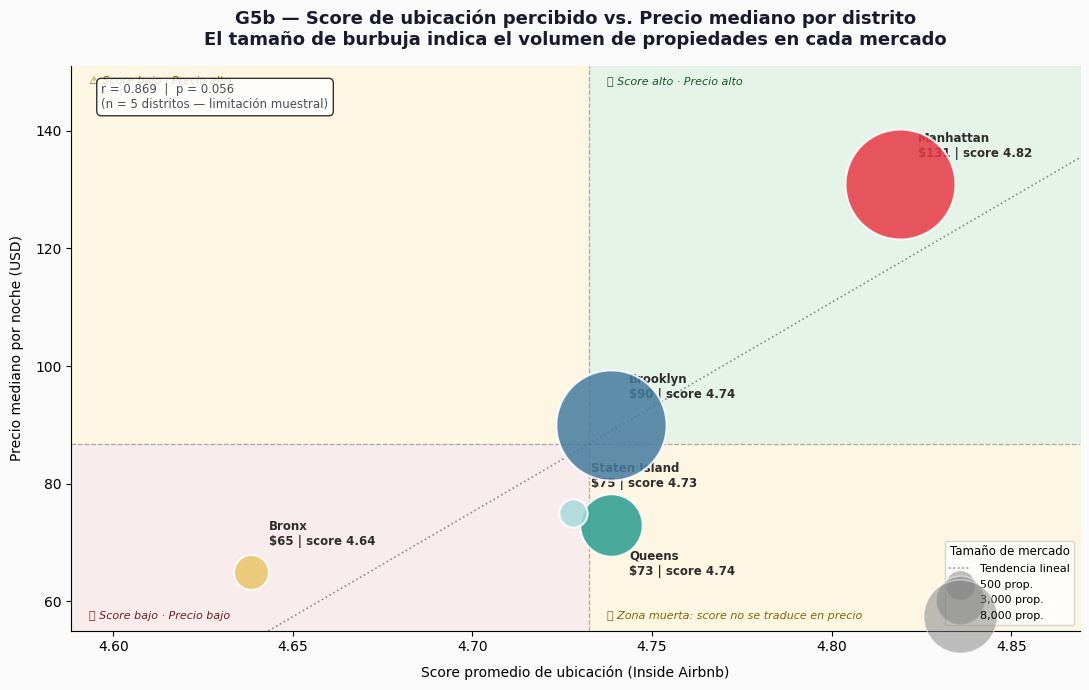


📊 Tabla resumen G5b:
     distrito  score_ubicacion_promedio  precio_mediano  n_propiedades
    Manhattan                  4.819128           131.0          19203
     Brooklyn                  4.738623            90.0          19323
Staten Island                  4.728092            75.0            365
       Queens                  4.738668            73.0           5557
        Bronx                  4.638288            65.0           1066

📐 Correlación Pearson: r = 0.869 | p-value = 0.056
⚠️  El p-value no alcanza significancia estadística (n=5 distritos).
    Se interpreta como tendencia descriptiva, no inferencial.


In [ ]:
# G5b - SCORE DE UBICACIÓN VS. PRECIO MEDIANO POR DISTRITO CON TAMAÑO DE MERCADO Y CUADRANTES DE INTERPRETACIÓN
# Extiende G5 añadiendo:
# Tamaño de burbuja proporcional al número de propiedades
# Cuadrantes que segmentan los 4 patrones posibles
# Anotación explícita del caso Manhattan (score + precio premium)
# Franja de "zona muerta": score alto pero precio bajo
# Variables: score_ubicacion_promedio × precio_mediano × n_propiedades

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Preparar datos: merge score + precio mediano + conteo
precio_por_distrito = (df_airbnb.groupby('neighbourhood_group')['price']
                       .median()
                       .reset_index()
                       .rename(columns={'neighbourhood_group': 'distrito',
                                        'price': 'precio_mediano'}))

conteo_por_distrito = (df_airbnb.groupby('neighbourhood_group')
                       .size()
                       .reset_index(name='n_propiedades')
                       .rename(columns={'neighbourhood_group': 'distrito'}))

df_g5b = (df_scores_ubicacion
          .merge(precio_por_distrito, on='distrito')
          .merge(conteo_por_distrito, on='distrito'))

# Umbrales de cuadrantes
score_mid  = df_g5b['score_ubicacion_promedio'].mean()
precio_mid = df_g5b['precio_mediano'].mean()

# Paleta por distrito
colores = {
    'Manhattan':    '#E63946',
    'Brooklyn':     '#457B9D',
    'Queens':       '#2A9D8F',
    'Bronx':        '#E9C46A',
    'Staten Island':'#A8DADC'
}

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Fondo de cuadrantes
x_min, x_max = df_g5b['score_ubicacion_promedio'].min() - 0.05, df_g5b['score_ubicacion_promedio'].max() + 0.05
y_min, y_max = df_g5b['precio_mediano'].min() - 10, df_g5b['precio_mediano'].max() + 20

ax.fill_betweenx([precio_mid, y_max], x_min, score_mid,
                 color='#FFF3CD', alpha=0.5, label='_nolegend_')  # score bajo, precio alto
ax.fill_betweenx([precio_mid, y_max], score_mid, x_max,
                 color='#D4EDDA', alpha=0.5, label='_nolegend_')  # score alto, precio alto ← ideal
ax.fill_betweenx([y_min, precio_mid], x_min, score_mid,
                 color='#F8D7DA', alpha=0.4, label='_nolegend_')  # score bajo, precio bajo
ax.fill_betweenx([y_min, precio_mid], score_mid, x_max,
                 color='#FFF3CD', alpha=0.5, label='_nolegend_')  # score alto, precio bajo ← zona muerta

# Etiquetas de cuadrantes
ax.text(score_mid + 0.005, y_max - 3,  '✅ Score alto · Precio alto',
        fontsize=8, color='#155724', fontstyle='italic', ha='left')
ax.text(x_min + 0.005, y_max - 3,      '⚠️ Score bajo · Precio alto',
        fontsize=8, color='#856404', fontstyle='italic', ha='left')
ax.text(score_mid + 0.005, y_min + 2,  '🔸 Zona muerta: score no se traduce en precio',
        fontsize=8, color='#856404', fontstyle='italic', ha='left')
ax.text(x_min + 0.005, y_min + 2,      '❌ Score bajo · Precio bajo',
        fontsize=8, color='#721C24', fontstyle='italic', ha='left')

# Líneas de cuadrante
ax.axvline(score_mid,  color='gray', linestyle='--', linewidth=0.9, alpha=0.6)
ax.axhline(precio_mid, color='gray', linestyle='--', linewidth=0.9, alpha=0.6)

# Línea de tendencia
z = np.polyfit(df_g5b['score_ubicacion_promedio'], df_g5b['precio_mediano'], 1)
p = np.poly1d(z)
x_line = np.linspace(x_min, x_max, 100)
ax.plot(x_line, p(x_line), color='#6C757D', linewidth=1.2,
        linestyle=':', alpha=0.8, label='Tendencia lineal')

# Burbujas
size_scale = 6000 / df_g5b['n_propiedades'].max()

for _, row in df_g5b.iterrows():
    distrito = row['distrito']
    color    = colores.get(distrito, '#999999')
    size     = row['n_propiedades'] * size_scale + 300

    ax.scatter(row['score_ubicacion_promedio'], row['precio_mediano'],
               s=size, color=color, alpha=0.85,
               edgecolors='white', linewidth=1.5, zorder=5)

    # Etiqueta del distrito
    offset_x = 0.005
    offset_y = 4 if distrito != 'Queens' else -9
    ax.annotate(
        f"{distrito}\n${row['precio_mediano']:.0f} | score {row['score_ubicacion_promedio']:.2f}",
        xy=(row['score_ubicacion_promedio'], row['precio_mediano']),
        xytext=(row['score_ubicacion_promedio'] + offset_x,
                row['precio_mediano'] + offset_y),
        fontsize=8.5, color='#2D2D2D', fontweight='bold',
        ha='left', va='bottom'
    )

# Leyenda de tamaño
for n, label in [(500, '500 prop.'), (3000, '3,000 prop.'), (8000, '8,000 prop.')]:
    ax.scatter([], [], s=n * size_scale + 300, color='gray',
               alpha=0.5, label=label, edgecolors='white')

ax.legend(title='Tamaño de mercado', loc='lower right',
          fontsize=8, title_fontsize=8.5, framealpha=0.8)

# Correlación en el gráfico
from scipy import stats
corr_val, pval = stats.pearsonr(df_g5b['score_ubicacion_promedio'],
                                df_g5b['precio_mediano'])
ax.text(0.03, 0.97,
        f"r = {corr_val:.3f}  |  p = {pval:.3f}\n(n = {len(df_g5b)} distritos — limitación muestral)",
        transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top', color='#495057',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

#  Títulos y ejes
ax.set_title('G5b — Score de ubicación percibido vs. Precio mediano por distrito\n'
             'El tamaño de burbuja indica el volumen de propiedades en cada mercado',
             fontsize=13, fontweight='bold', pad=15, color='#1A1A2E')
ax.set_xlabel('Score promedio de ubicación (Inside Airbnb)', fontsize=10, labelpad=8)
ax.set_ylabel('Precio mediano por noche (USD)', fontsize=10, labelpad=8)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Lectura analítica
print("\n📊 Tabla resumen G5b:")
print(df_g5b[['distrito', 'score_ubicacion_promedio', 'precio_mediano', 'n_propiedades']]
      .sort_values('precio_mediano', ascending=False)
      .to_string(index=False))

print(f"\n📐 Correlación Pearson: r = {corr_val:.3f} | p-value = {pval:.3f}")
print("⚠️  El p-value no alcanza significancia estadística (n=5 distritos).")
print("    Se interpreta como tendencia descriptiva, no inferencial.")